# Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import datetime

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from gensim.utils import simple_preprocess

from scipy.stats import chisquare

import matplotlib.pyplot as plt

In [2]:
random.seed(42)

In [ ]:
themes = ['hypersexualizing', 'pathologizing', 'sexuality', 'gender', 'discrediting', 'immigration', 'poverty', 'addiction', 
          'racial tropes', 'parenting', 'mental health']

keywords = {
    'hypersexualizing' : {
        'neutral' : ['flaunt', 'appeal', 'reveal', 'underwear', 'sex', 'tease', 'lure', 'entice', 'flirt', 'seduce', 'affair', 'adultery', 
                     'promiscuous', 'charm', 'sexy', 'glamour', 'attractive', 'ass', 'booty', 'oversexed'],
        'feminine' : ['busty', 'bra', 'panty', 'lingerie', 'teddy', 'slut', 'whore', 'bimbo', 'floozy', 'bitch', 'jezebel', 'mistress', 
                      'breast', 'cleavage', 'skank', 'cougar', 'temptress'],
        'masculine' : ['boxers', 'womanizer']},
    'pathologizing' : {
        'neutral' : ['calculated', 'cold', 'inhuman', 'unnatural', 'unstable', 'fake', 'deranged', 'tears', 'unemotional', 'liar', 'malinger', 
                     'uncontrollable', 'angry', 'insincere', 'unempathetic', 'lie', 'irrational', 'hysterical', 
                     'scheme', 'cry', 'manipulate'],
        'feminine' : [],
        'masculine' : []},
    'sexuality' : {
        'neutral' : ['bisexual', 'queer'],
        'feminine' : ['bitch', 'dyke', 'butch','lesbian'],
        'masculine' : ['gay']},
    'gender' : {
        'neutral' : ['nurture', 'homemaker', 'virgin', 'pure', 'sacrificial', 'cold', 'uncaring', 'unfriendly', 'unemotional', 'abandonment', 
                     'neglect', 'overbearing','selfish', 'unnatural', 'assertive', 'ugly', 'aggressive', 'confrontational', 'violent', 'unfeeling', 'abuse', 'attractive', 'caring', 'friendly', 'emotional', 'materialistic', 'selfish'],
        'feminine' : ['maternal', 'feminine', 'wife', 'lady', 'woman', 'female', 'housewife'],
        'masculine' : ['paternal', 'masculine', 'husband', 'man', 'male']},
    'discrediting' : {
        'neutral' : ['liar', 'lie', 'unbelievable', 'unreliable', 'inconsistent', 'corroborate', 'atypical', 'manipulate', 
                     'exaggerate', 'hysterical'],
        'feminine' : [],
        'masculine' : []},
    'immigration' : {
        'neutral' : ['infiltrate', 'alien', 'foreign', 'backward', 'home', 'citizenship', 'wetback', 'illegal', 'dirty', 'untrustworthy'
                     'exotic', 'diverse', 'different', 'ethnic', 'accent', 'english', 'custom', 'culture', 'steal'],
        'feminine' : [],
        'masculine' : []},
    'poverty' : {
        'neutral' : ['poor', 'welfare', 'poverty', 'lazy', 'cheap', 'dirty', 'disorganized', 'messy', 'greedy', 'materialistic', 
                     'acquisitive', 'motel', 'trailer', 'trash'],
        'feminine' : [],
        'masculine' : []},
    'addiction' : {
        'neutral' : ['cocaine', 'speed', 'marijuana', 'heroin', 'addict', 'drug', 'methamphetamine', 'brain', 'meth', 'influence',
                     'nanograms', 'alcohol', 'stimulant', 'valium', 'crack', 'crystal', 'gram', 'crack house'],
        'feminine' : [],
        'masculine' : []},
    'racial tropes' : {
        'neutral' : ['negro', 'feral', 'lazy', 'brute', 'angry', 'untamable', 'gang', 'lazy', 'welfare', 'savage', 'animal', 'belligerent',
                     'angry', 'thug', 'culture', 'customs', 'different', 'diverse', 'foreign', 'exotic', 'accent', 'steal', 'english', 'foreign', 'backward', 'community', 'dirty', 'ethnic', 'infiltrate'],
        'feminine' : ['mammy', 'matriarch', 'welfare queen', 'mama'],
        'masculine' : ['patriarch', 'daddy']},
    'parenting' : {
        'neutral' : ['abuse', 'caring', 'negligent', 'nurture', 'neglect', 'therapy', 'respect', 'foster', 
                     'minor', 'parents', 'therapist'],
        'feminine' : ['mom', 'mother', 'maternal', 'matriarch'],
        'masculine' : ['dad', 'father', 'paternal', 'patriarch']}, 
    'mental health' : {
        'neutral' : ['disorder', 'mental', 'depression', 'bipolar', 'antisocial' , 'criteria', 'manic', 'lithium', 'prozac', 'medication',
                     'psychosis', 'prednisone', 'medications', 'xanax', 'prescribed', 'effects','battered', 'violence','domestic', 'syndrome', 'abuse', 'iq', 'performance', 'average', 'brain', 'impairment', 'functioning', 'disability', 'learning','satanic', 'diagnose'],
        'feminine' : [],
        'masculine' : []
    }}

df_keywords = pd.DataFrame()
for theme in themes:
    for gender in ['neutral', 'feminine', 'masculine']:
        tmp = pd.DataFrame({'theme' : theme, 'keyword_gender' : gender, 'keyword' : keywords[theme][gender]})
        df_keywords = pd.concat([tmp, df_keywords])

In [4]:
unique_keywords = []

for theme in themes:
    for gender in ['neutral', 'feminine', 'masculine']:
        words = [PorterStemmer().stem(word) for word in keywords[theme][gender]]

        unique_keywords = unique_keywords + words

unique_keywords = list(set(unique_keywords))

## Read and Preprocess Transcript Files

In [5]:
def read_text_files(path='/Users/emmharv/Downloads/capitaltrialtranscripts/'):

    files = []
    transcripts = []
    genders = []

    for gender in ['women', 'mixed', 'men']:
        for file in os.listdir(os.path.join(path, gender)):
            if 'txt' in file:
                try:
                    with open(os.path.join(path, gender, file), 'r', encoding='utf-8', errors='ignore') as f:
                        transcript = f.read()
                        files.append(file)
                        transcripts.append(transcript)
                        genders.append(gender)
                except:
                    print('error for ', file)

    df = pd.DataFrame({'id' : files, 'transcript' : transcripts, 'gender' : genders})

    return df

df = read_text_files()

In [6]:
df['transcript_cleaned'] = df['transcript'].str.replace(r'[^a-zA-Z\s]', '', regex=True) ## remove characters other than alpha and whitespace
df['transcript_cleaned'] = df['transcript_cleaned'].str.lower() ## lowercase

stop = stopwords.words('english')
stop.extend(['q', 'a', 'question', 'answer', 'mr', 'ms', 'miss', 'sir', 'maam', 'court', 'judge', 'jury', 'juror', 'testimony', 'witness', 'honor',
             'defendant', 'defense', 'record', 'objection', 'exhibit', 'evidence', 'statement', 'case', 
             'yes', 'right', 'would', 'okay', 'know', 'time', 'thats', 'dont', 'one', 'going', 'well', 'correct', 'think', 'im', 'like']) ## remove transcript artifacts, general trial words

df['transcript_cleaned'] = df['transcript_cleaned'].apply(simple_preprocess) ## tokenize
df['transcript_cleaned'] = df['transcript_cleaned'].apply(lambda x: [word for word in x if word not in (stop)]) ## stopwords

df['transcript_cleaned_stemmed'] = df['transcript_cleaned'].apply(lambda x: [PorterStemmer().stem(word) for word in x]) ## stem


In [20]:
df_agg = df.groupby('gender')['transcript_cleaned_stemmed'].agg('sum').reset_index()
df_agg['total_words'] = df_agg.apply(lambda x: len(x['transcript_cleaned_stemmed']), axis=1)
df_agg

,gender,transcript_cleaned_stemmed,total_words
0,men,"[close, argument, rest, instruct, give, law, t...",13237890
1,mixed,"[requir, keep, two, separ, compart, brain, spe...",2357634
2,women,"[mind, trial, form, final, opinion, youv, oppo...",7718991


# Calculate Concatenated Metrics

In [21]:
bootstrapped_metrics_keyword = pd.DataFrame()
bootstrapped_metrics_theme = pd.DataFrame()

then = datetime.datetime.now()
for n in range(1001):

    ## Print progress
    if (n % 50) == 0:
        now = datetime.datetime.now()
        print(n, now - then)
        then = now


    ## Generate data
    if n == 0: ## point estimate
        tmp = df_agg.copy()
    else: ## bootstrap
        tmp = df.groupby('gender')[['id', 'transcript', 'gender', 'transcript_cleaned', 'transcript_cleaned_stemmed']].apply(lambda x: x.sample(frac=1.0, replace=True)).reset_index(drop=True)
        tmp = tmp.groupby('gender')['transcript_cleaned_stemmed'].agg('sum').reset_index()
        tmp['total_words'] = tmp.apply(lambda x: len(x['transcript_cleaned_stemmed']), axis=1)

    txt = tmp['transcript_cleaned_stemmed']


    ## Raw counts
    counts_cleaned_stemmed = txt.apply(Counter, axis=1)
    for word in unique_keywords:
        tmp[word] = 0
        tmp = tmp.copy()
        for i in range(len(counts_cleaned_stemmed)):
            tmp.loc[i, word] = counts_cleaned_stemmed[i][word]

    tmp_counts = pd.melt(tmp.drop(columns='transcript_cleaned_stemmed'), id_vars=['gender', 'total_words'], var_name='keyword', value_name='keyword_count')
    

    ## KEYWORD METRICS ##

    ## Normalized term frequency
    tmp_counts['keyword_normalized_term_frequency'] = tmp_counts['keyword_count'] / tmp_counts['total_words']

    ## c-TF-IDF, following https://maartengr.github.io/BERTopic/api/ctfidf.html#bertopic.vectorizers.ClassTfidfTransformer
    A = tmp['total_words'].mean()
    f = tmp_counts.groupby('keyword')['keyword_count'].sum().reset_index()

    tmp_ctfidf = tmp_counts.copy().drop(columns='keyword_count')
    tmp_ctfidf['A'] = A
    tmp_ctfidf = pd.merge(tmp_ctfidf, f)

    tmp_ctfidf['cTFIDF'] = np.sqrt(tmp_ctfidf['keyword_normalized_term_frequency']) * np.log(1 + tmp_ctfidf['A'] / tmp_ctfidf['keyword_count'])


    ## THEME METRICS ##

    ## Raw theme count, normalized theme frequency
    tmp_theme_counts = pd.merge(tmp_counts, df_keywords).groupby(['gender', 'total_words', 'theme'])[['keyword_count', 'keyword_normalized_term_frequency']].sum().reset_index()
    tmp_theme_counts.columns = ['gender', 'total_words', 'theme', 'theme_keyword_count', 'theme_keyword_normalized_term_frequency']

    ## c-SF-IDF, following: 
    ## https://maartengr.github.io/BERTopic/api/ctfidf.html#bertopic.vectorizers.ClassTfidfTransformer,
    ## https://dl.acm.org/doi/10.1145/2254129.2254163
    f = tmp_theme_counts.groupby('theme')['theme_keyword_count'].sum().reset_index()

    tmp_theme_ctfidf = tmp_theme_counts.copy().drop(columns='theme_keyword_count')
    tmp_theme_ctfidf['A'] = A
    tmp_theme_ctfidf = pd.merge(tmp_theme_ctfidf, f)

    tmp_theme_ctfidf['theme_cSFIDF'] = np.sqrt(tmp_theme_ctfidf['theme_keyword_normalized_term_frequency']) * np.log(1 + tmp_theme_ctfidf['A'] / tmp_theme_ctfidf['theme_keyword_count'])


    ## Save outputs
    tmp_keyword_save = pd.merge(tmp_counts[['gender', 'total_words', 'keyword', 'keyword_count', 'keyword_normalized_term_frequency']], 
                                tmp_ctfidf[['gender', 'keyword', 'cTFIDF']])
    
    tmp_theme_save = pd.merge(tmp_theme_counts[['gender', 'total_words', 'theme', 'theme_keyword_count', 'theme_keyword_normalized_term_frequency']], 
                              tmp_theme_ctfidf[['gender', 'theme', 'theme_cSFIDF']])
    
    if n == 0: ## point estimate
        tmp_keyword_save['id'] = 'point estimate'
        tmp_theme_save['id'] = 'point estimate'
    else: ## bootstrap
        tmp_keyword_save['id'] = 'bootstrap ' + str(n)
        tmp_theme_save['id'] = 'bootstrap ' + str(n)

    bootstrapped_metrics_keyword = pd.concat([tmp_keyword_save, bootstrapped_metrics_keyword])
    bootstrapped_metrics_theme = pd.concat([tmp_theme_save, bootstrapped_metrics_theme])

0 0:00:00.000521
50 0:04:29.873173
100 0:04:34.643984
150 0:04:42.393659
200 0:04:49.075553
250 0:04:44.839130
300 0:04:48.648800
350 0:04:47.294107
400 0:04:55.145427
450 0:04:39.147897
500 0:04:27.007543
550 0:04:47.938119
600 0:04:22.483373
650 0:04:31.048022
700 0:04:49.208118
750 0:04:37.219828
800 0:04:30.472700
850 0:04:20.534931
900 0:04:28.372085
950 0:04:25.186090
1000 0:04:22.748428


In [22]:
bootstrapped_metrics_keyword.to_csv('bootstrap_results_keyword.csv', index=False)
bootstrapped_metrics_theme.to_csv('bootstrap_results_theme.csv', index=False)

In [23]:
point_estimate_keyword = bootstrapped_metrics_keyword[bootstrapped_metrics_keyword['id'] == 'point estimate']
bootstrap_estimate_keyword = bootstrapped_metrics_keyword[bootstrapped_metrics_keyword['id'] != 'point estimate']

ci_l_keyword = bootstrap_estimate_keyword.groupby(['gender', 'keyword'])[['keyword_count', 'keyword_normalized_term_frequency', 'cTFIDF']].agg(lambda x : np.percentile(x, 2.5)).add_suffix('_L').reset_index()
ci_u_keyword = bootstrap_estimate_keyword.groupby(['gender', 'keyword'])[['keyword_count', 'keyword_normalized_term_frequency', 'cTFIDF']].agg(lambda x : np.percentile(x, 97.5)).add_suffix('_U').reset_index()

keyword_ci = pd.merge(point_estimate_keyword, pd.merge(ci_l_keyword, ci_u_keyword))
keyword_ci

,gender,total_words,keyword,keyword_count,keyword_normalized_term_frequency,cTFIDF,id,keyword_count_L,keyword_normalized_term_frequency_L,cTFIDF_L,keyword_count_U,keyword_normalized_term_frequency_U,cTFIDF_U
0,men,13237890,home,14225,0.001075,0.183514,point estimate,11617.250,0.000935,0.173201,16900.125,0.001226,0.193803
1,mixed,2357634,home,3349,0.001420,0.210995,point estimate,1752.000,0.000877,0.167285,5044.000,0.002001,0.248614
2,women,7718991,home,11321,0.001467,0.214395,point estimate,8592.925,0.001312,0.204182,14316.650,0.001654,0.226980
3,men,13237890,mother,9159,0.000692,0.157411,point estimate,7512.975,0.000594,0.147096,11095.375,0.000803,0.168330
4,mixed,2357634,mother,2126,0.000902,0.179706,point estimate,1426.000,0.000765,0.165519,2870.000,0.001061,0.195846
...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,mixed,2357634,maling,125,0.000053,0.064690,point estimate,3.000,0.000002,0.012970,360.000,0.000127,0.099041
629,women,7718991,maling,499,0.000065,0.071431,point estimate,147.925,0.000020,0.041336,933.075,0.000120,0.094296
630,men,13237890,trailer,2572,0.000194,0.101896,point estimate,1202.325,0.000092,0.072654,4862.725,0.000360,0.131419
631,mixed,2357634,trailer,783,0.000332,0.133221,point estimate,109.000,0.000058,0.058246,1888.575,0.000660,0.184789


In [25]:
point_estimate_theme = bootstrapped_metrics_theme[bootstrapped_metrics_theme['id'] == 'point estimate']
bootstrap_estimate_theme = bootstrapped_metrics_theme[bootstrapped_metrics_theme['id'] != 'point estimate']

ci_l_theme = bootstrap_estimate_theme.groupby(['gender', 'theme'])[['theme_keyword_count', 'theme_keyword_normalized_term_frequency', 'theme_cSFIDF']].agg(lambda x : np.percentile(x, 2.5)).add_suffix('_L').reset_index()
ci_u_theme = bootstrap_estimate_theme.groupby(['gender', 'theme'])[['theme_keyword_count', 'theme_keyword_normalized_term_frequency', 'theme_cSFIDF']].agg(lambda x : np.percentile(x, 97.5)).add_suffix('_U').reset_index()

theme_ci = pd.merge(point_estimate_theme, pd.merge(ci_l_theme, ci_u_theme))
theme_ci

,gender,total_words,theme,theme_keyword_count,theme_keyword_normalized_term_frequency,theme_cSFIDF,id,theme_keyword_count_L,theme_keyword_normalized_term_frequency_L,theme_cSFIDF_L,theme_keyword_count_U,theme_keyword_normalized_term_frequency_U,theme_cSFIDF_U
0,men,13237890,addiction,23265,0.001757,0.220611,point estimate,18888.950,0.001463,0.204711,28240.500,0.002069,0.236884
1,men,13237890,discrediting,6437,0.000486,0.141239,point estimate,5009.775,0.000417,0.131731,8104.800,0.000562,0.150416
2,men,13237890,gender,28126,0.002125,0.229097,point estimate,24254.525,0.001900,0.219019,32463.175,0.002382,0.239925
3,men,13237890,hypersexualizing,6033,0.000456,0.138008,point estimate,4407.900,0.000359,0.124649,8252.100,0.000603,0.154826
4,men,13237890,immigration,18294,0.001382,0.200139,point estimate,15239.050,0.001240,0.191312,21650.050,0.001535,0.208651
5,men,13237890,mental health,14597,0.001103,0.192340,point estimate,10628.775,0.000831,0.171844,18758.250,0.001406,0.211860
6,men,13237890,parenting,33915,0.002562,0.241392,point estimate,26787.050,0.002137,0.224231,43978.125,0.003088,0.260559
7,men,13237890,pathologizing,8136,0.000615,0.152037,point estimate,6486.875,0.000540,0.142870,10019.075,0.000692,0.160696
8,men,13237890,poverty,6513,0.000492,0.142022,point estimate,3995.475,0.000320,0.117658,9701.375,0.000713,0.165529
9,men,13237890,racial tropes,11691,0.000883,0.186015,point estimate,6768.125,0.000516,0.151132,18450.850,0.001311,0.215023


## Graphics

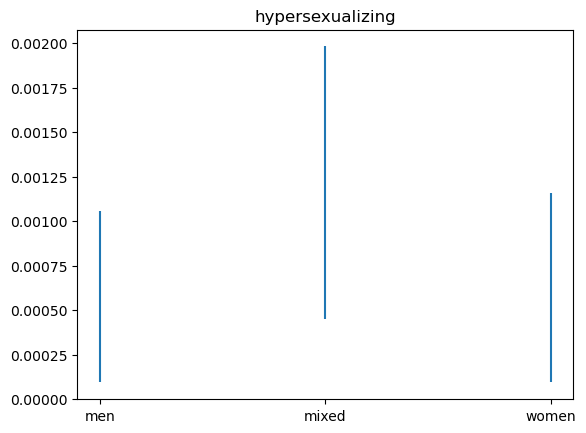

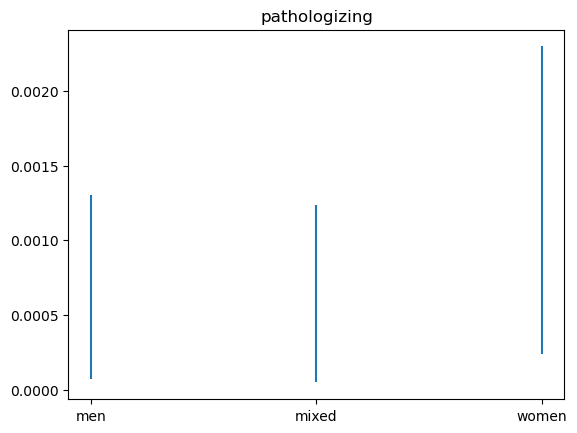

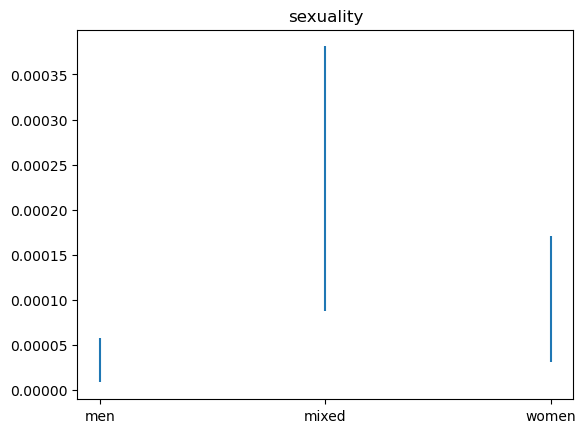

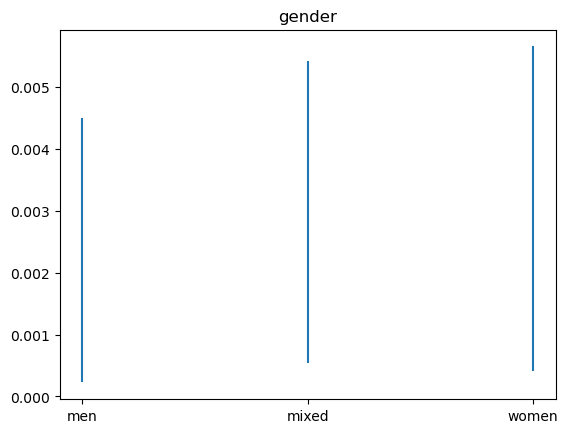

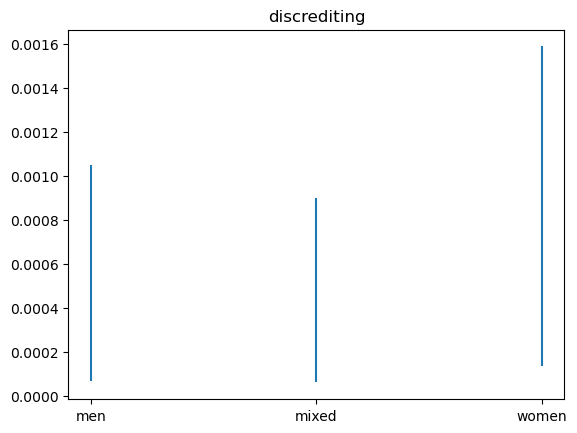

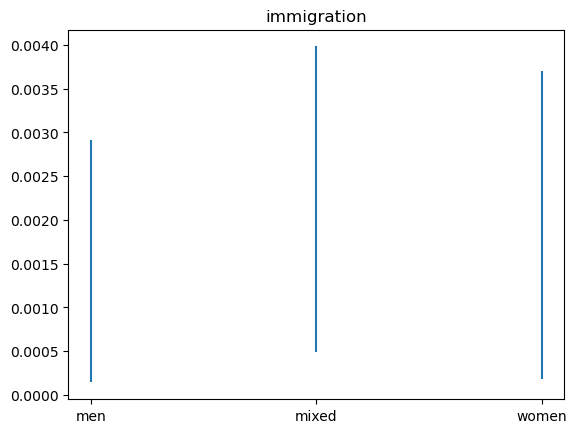

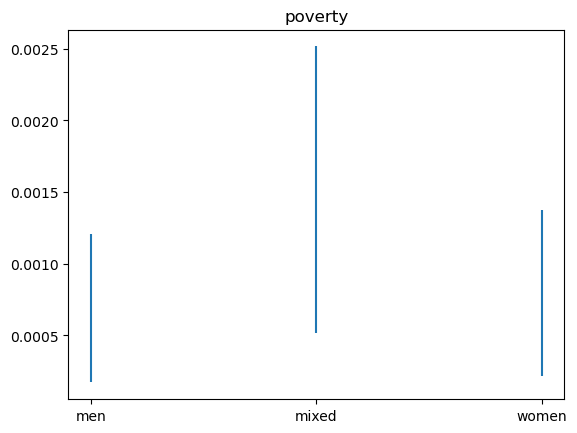

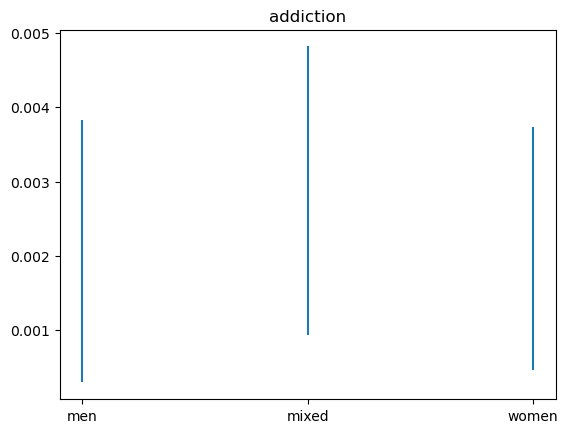

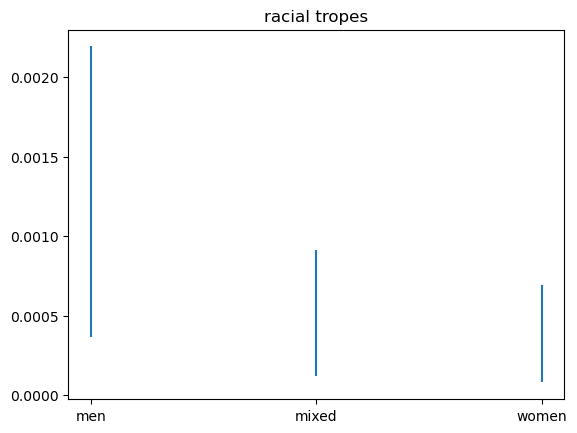

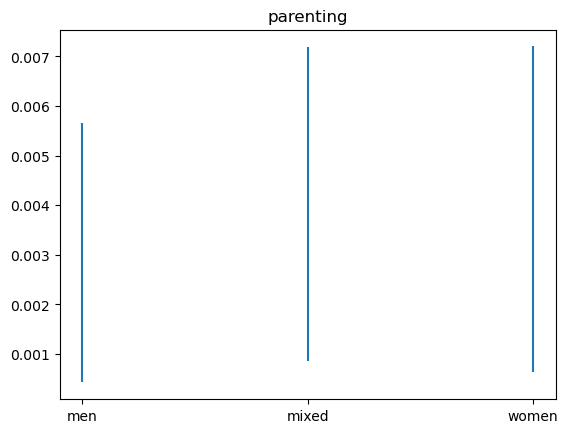

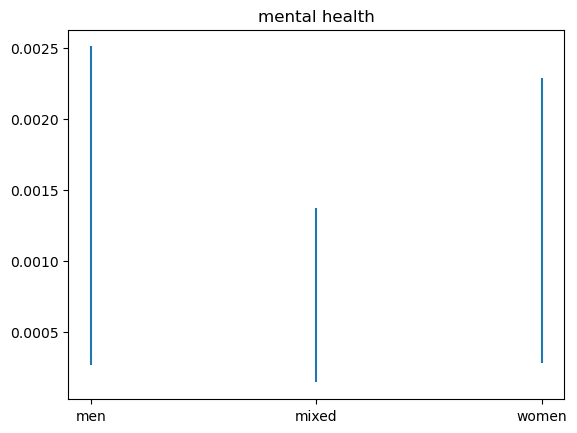

<Figure size 640x480 with 0 Axes>

In [33]:
for theme in themes:
    grph = theme_ci[theme_ci['theme'] == theme]
    plt.errorbar(x=grph['gender'], y=grph['theme_keyword_normalized_term_frequency'], 
                 yerr=(grph['theme_keyword_normalized_term_frequency_L'], grph['theme_keyword_normalized_term_frequency_U']), 
                 linestyle='None')
    plt.title(theme)
    plt.show()
    plt.clf()

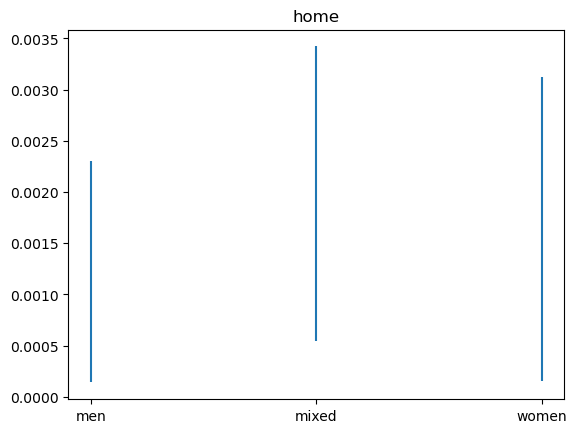

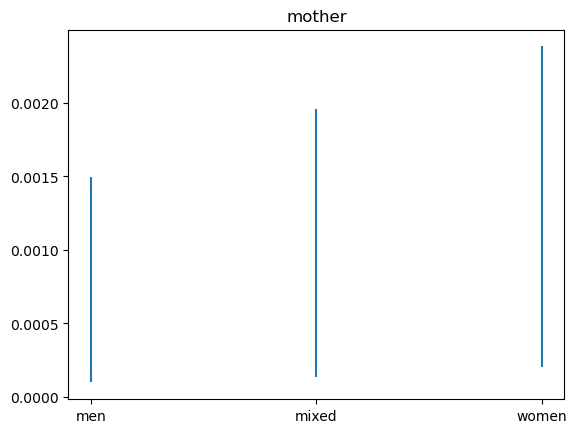

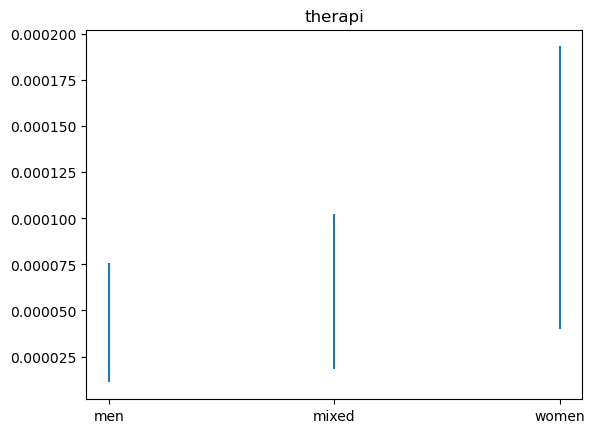

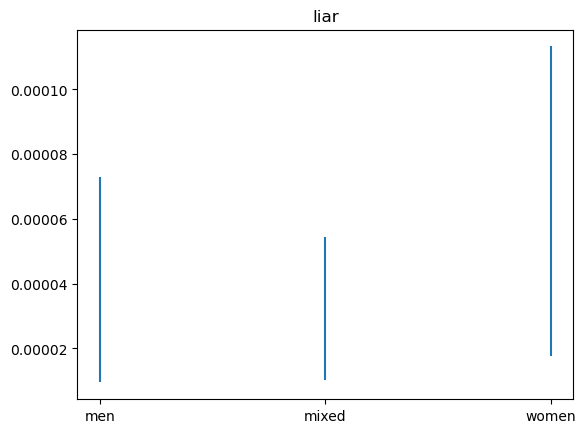

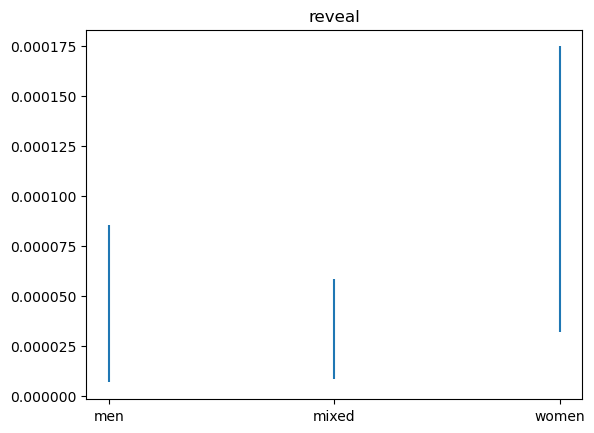

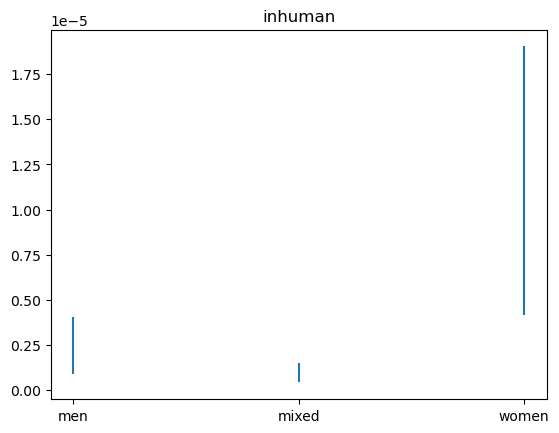

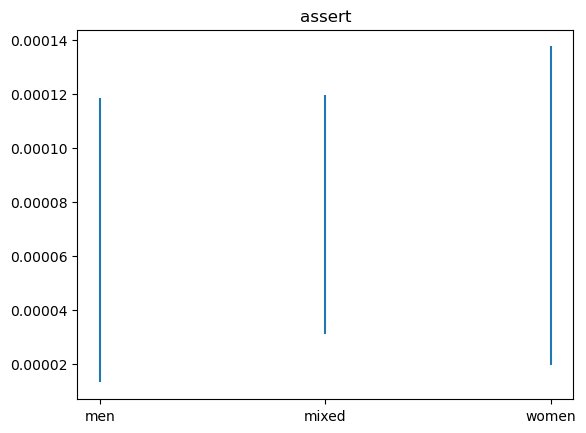

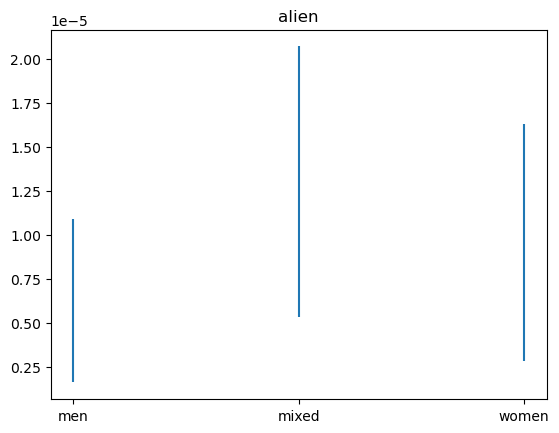

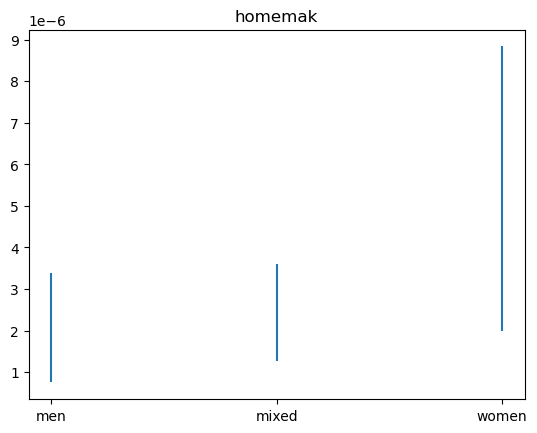

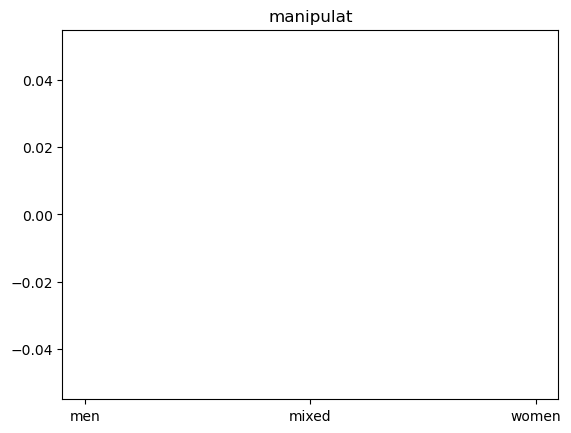

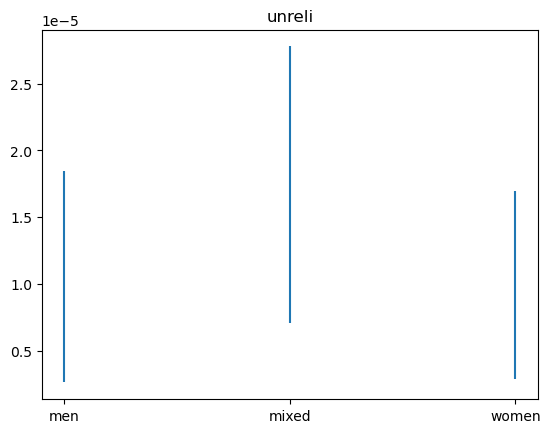

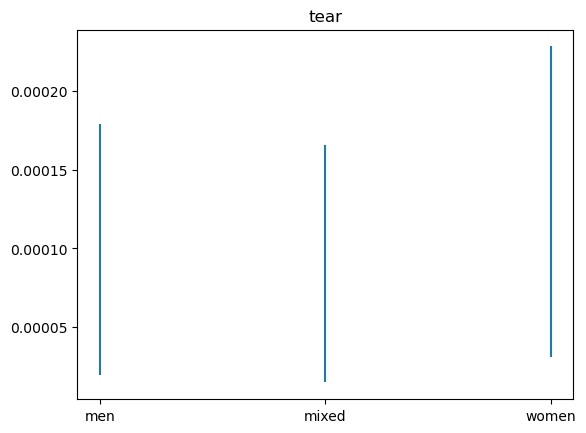

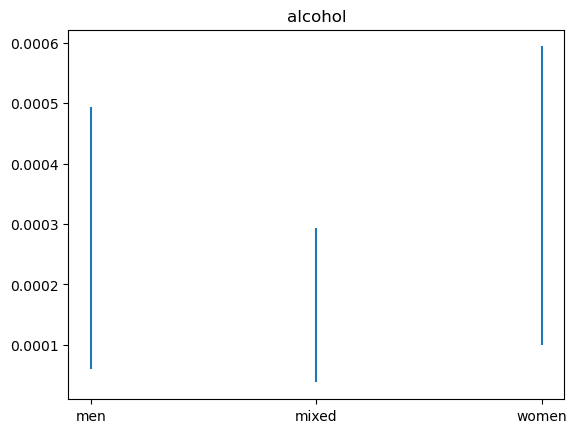

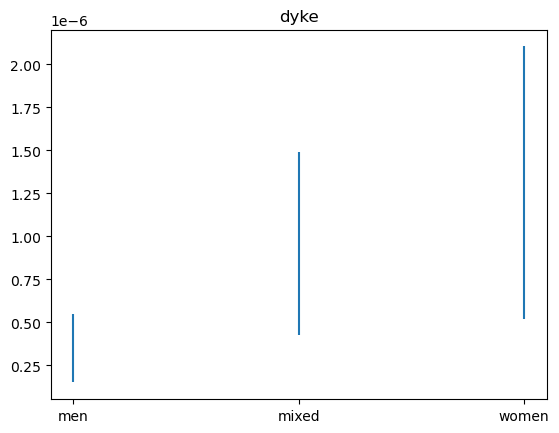

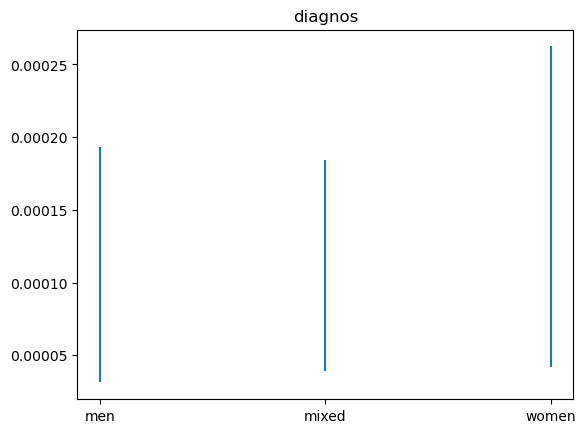

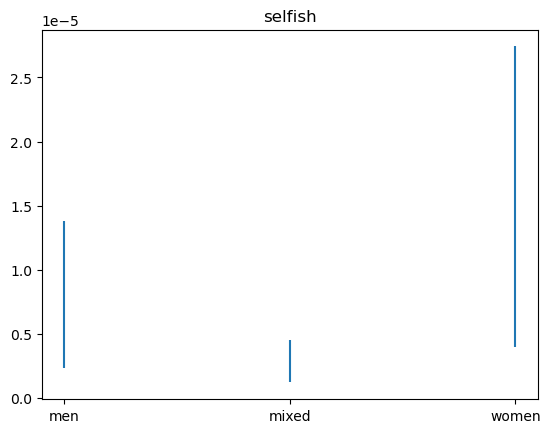

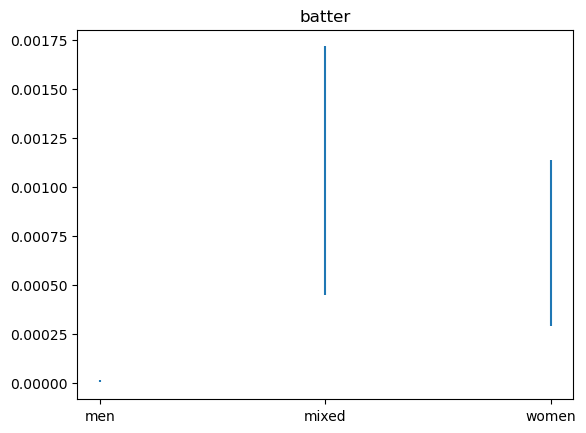

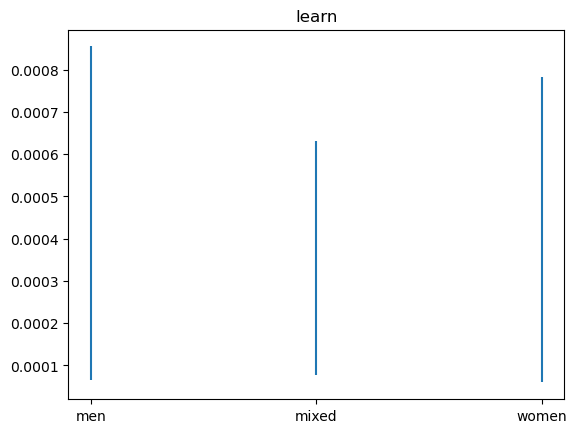

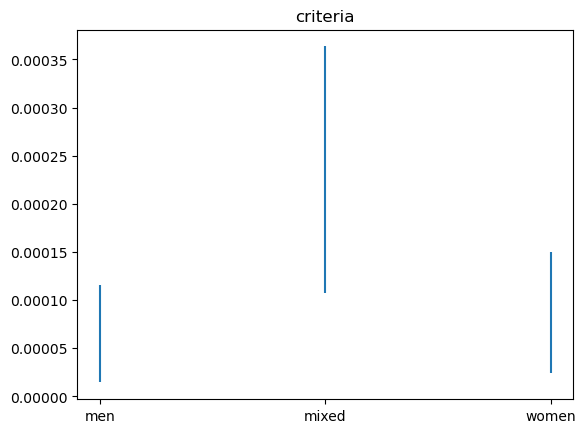

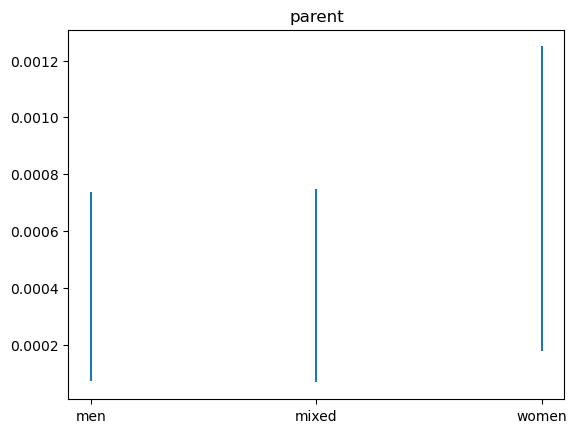

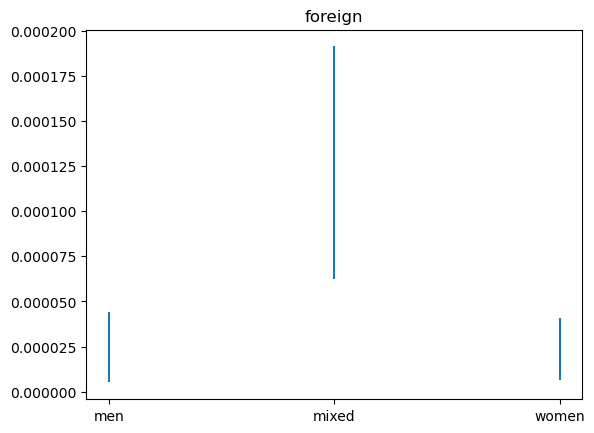

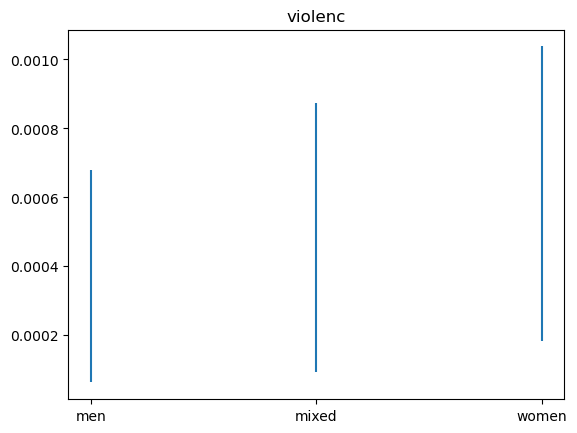

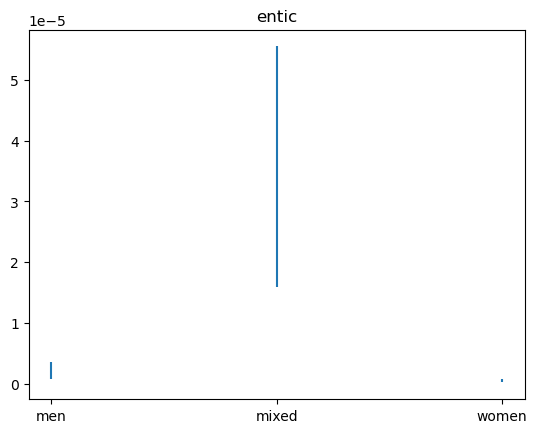

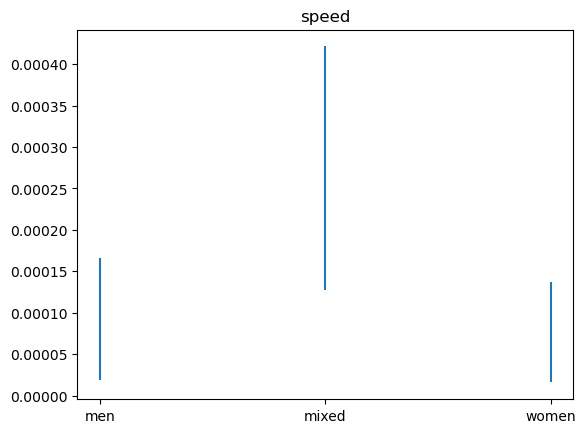

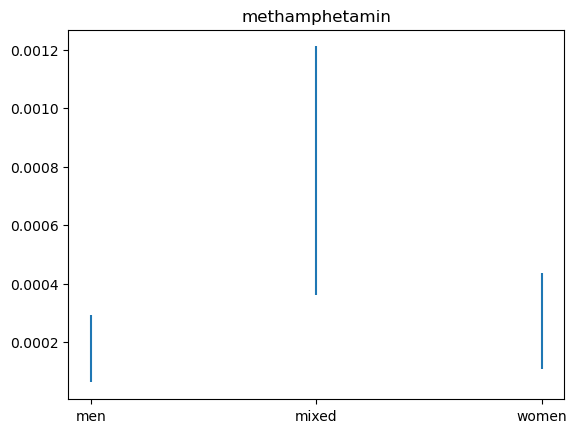

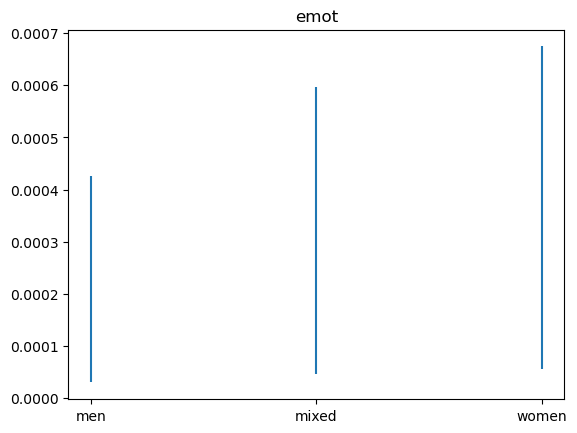

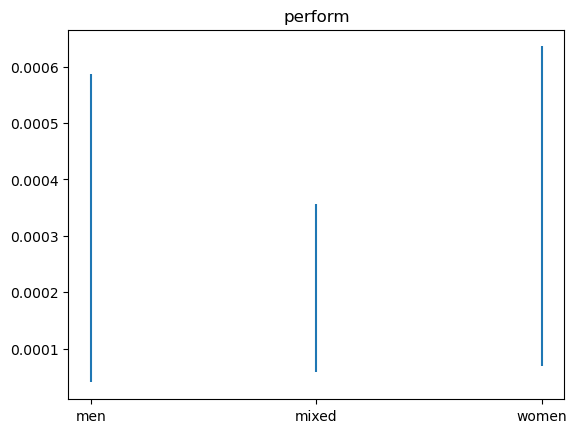

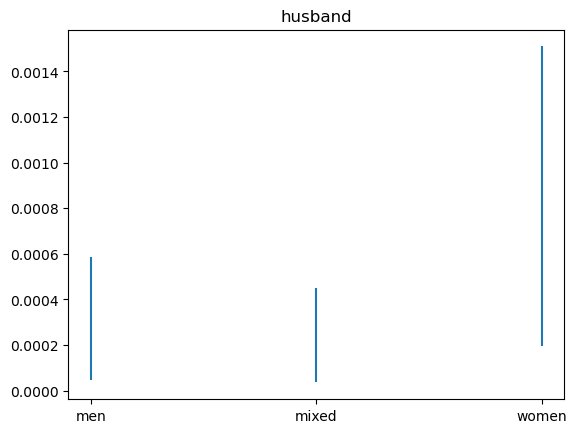

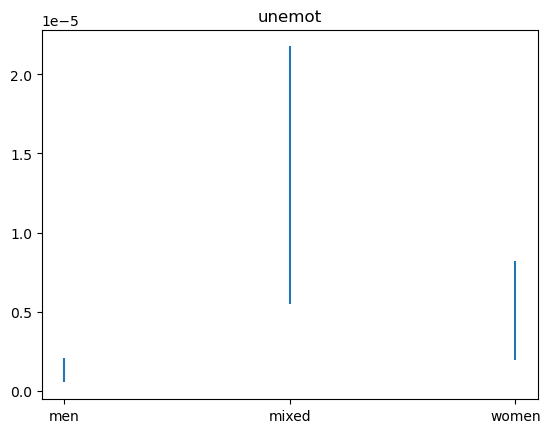

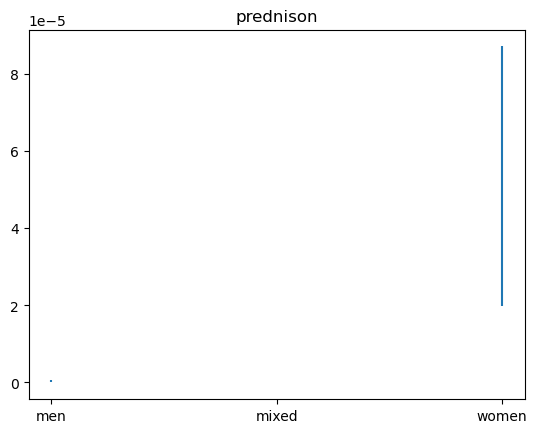

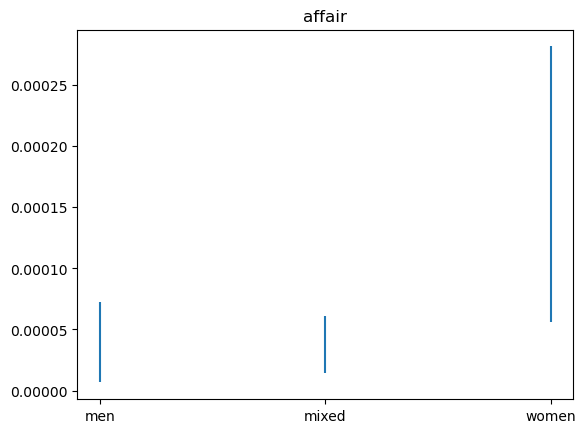

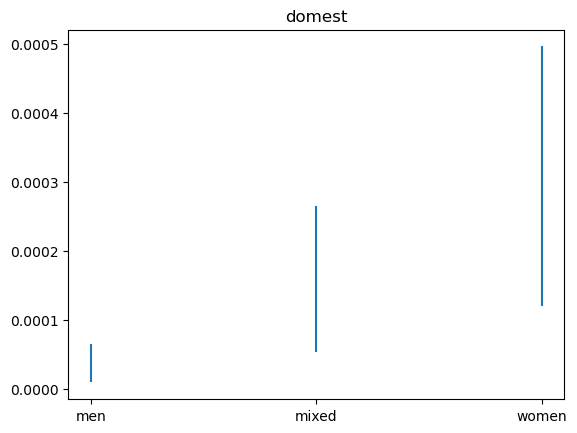

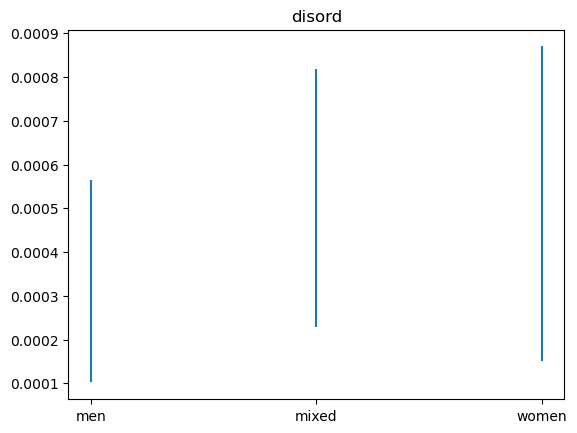

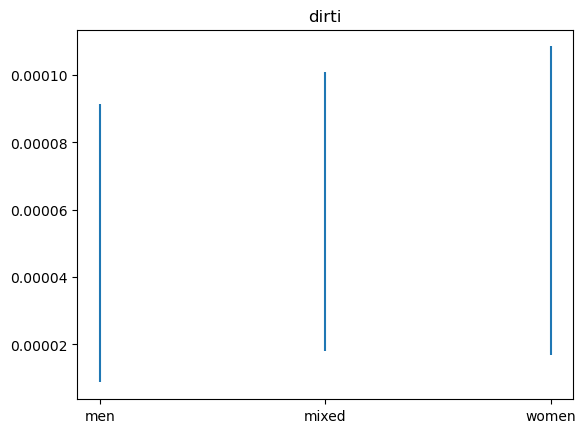

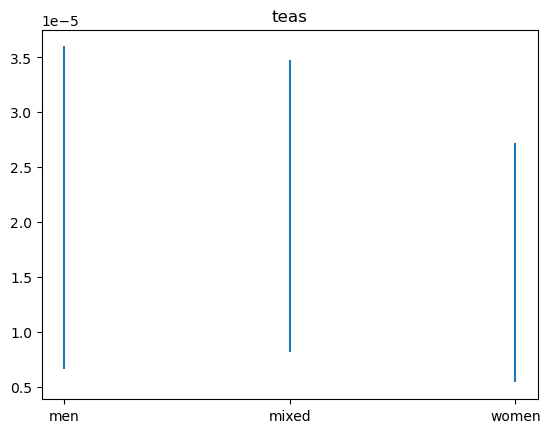

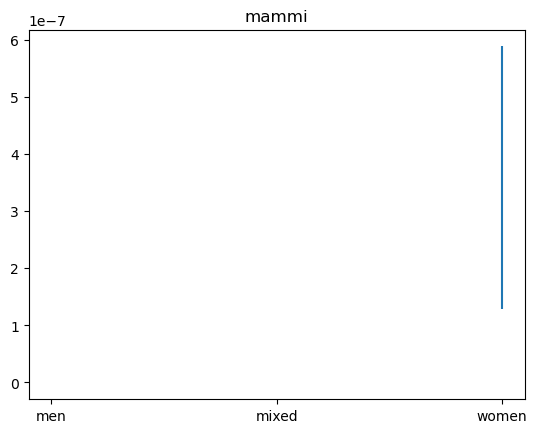

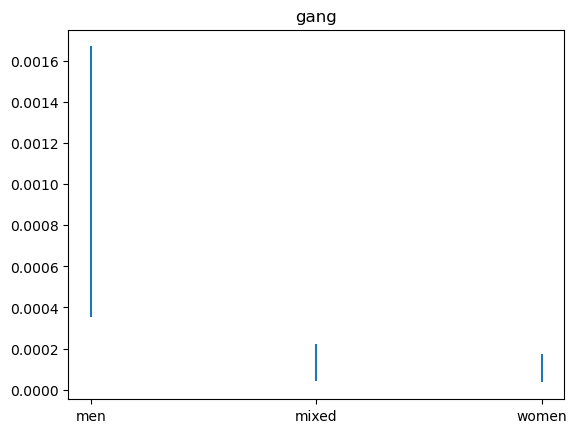

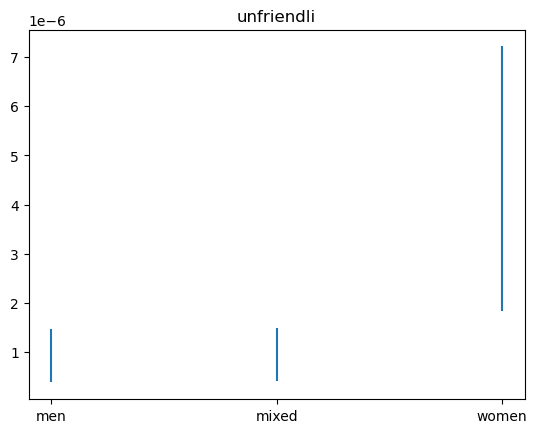

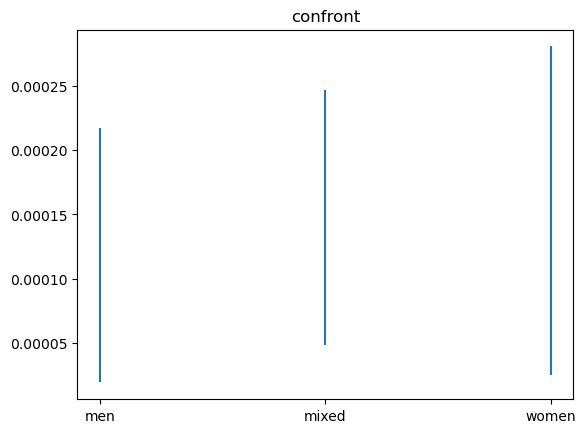

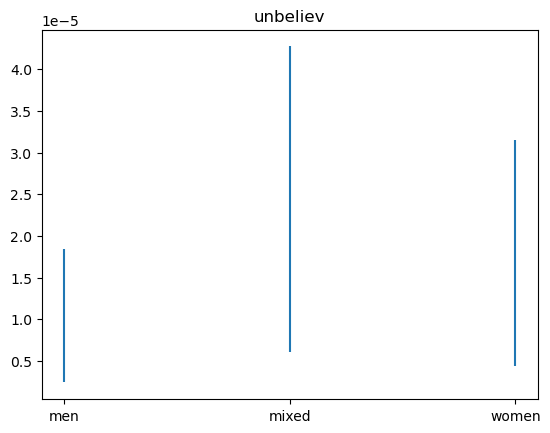

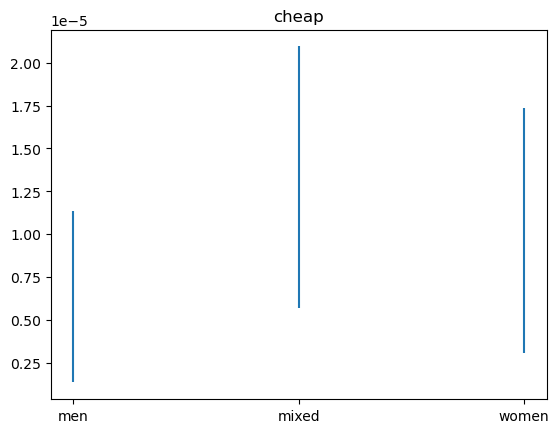

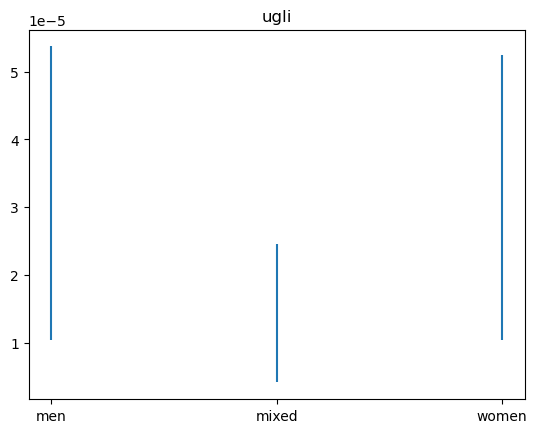

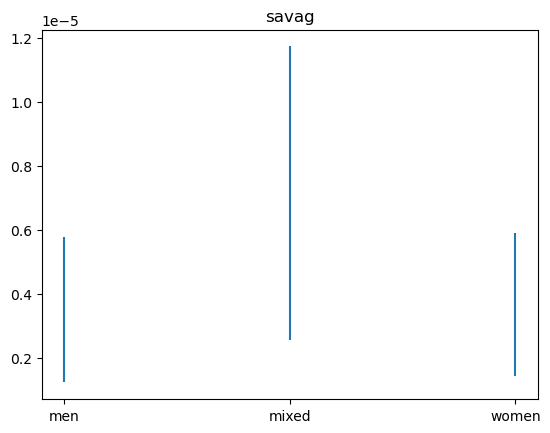

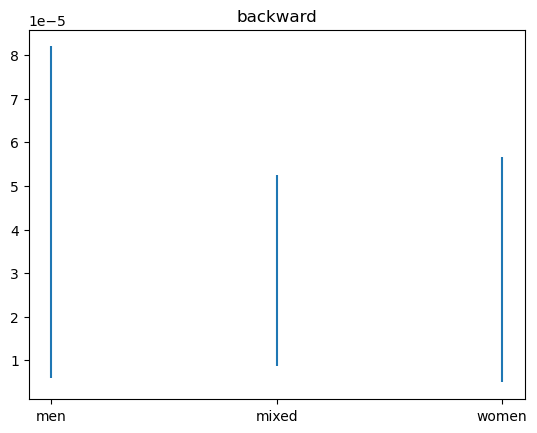

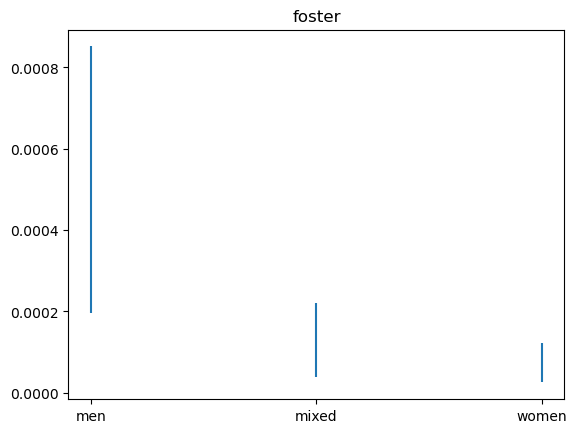

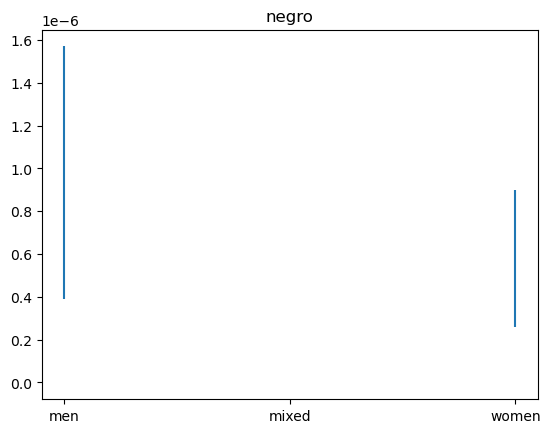

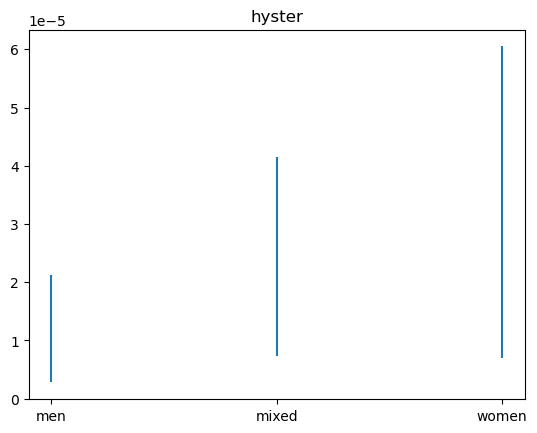

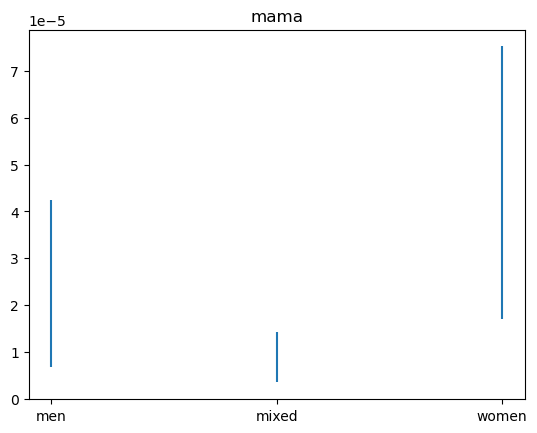

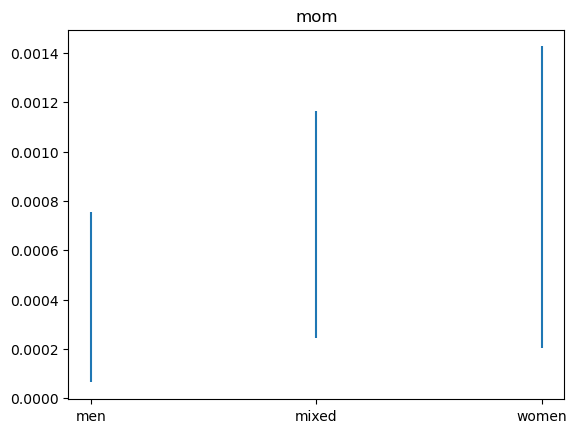

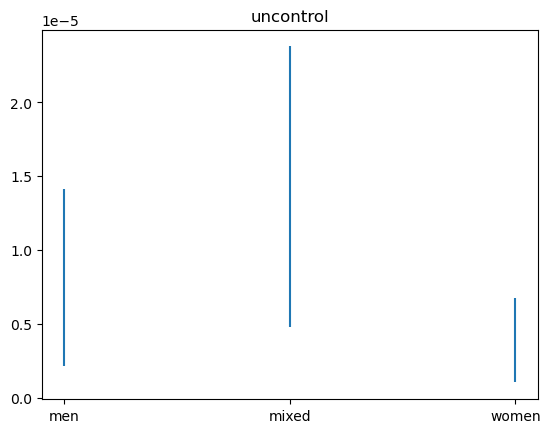

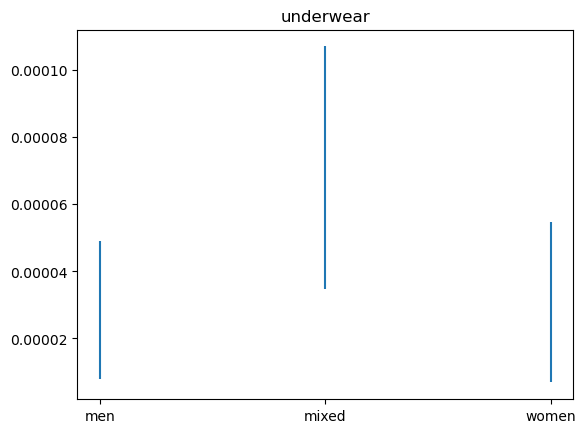

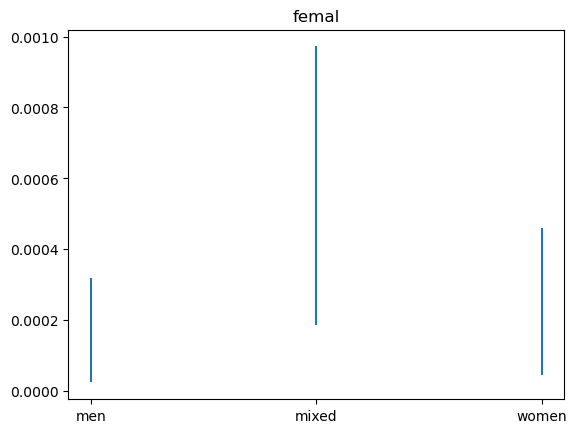

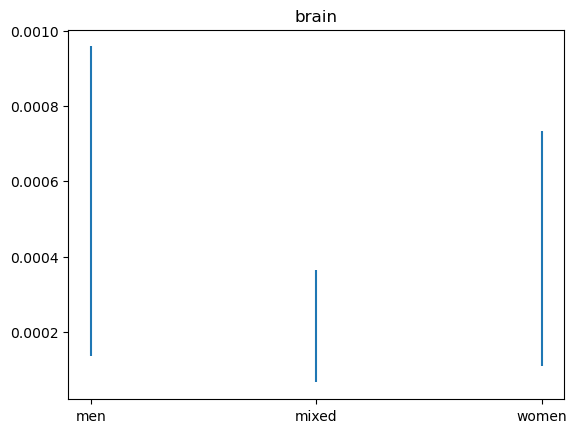

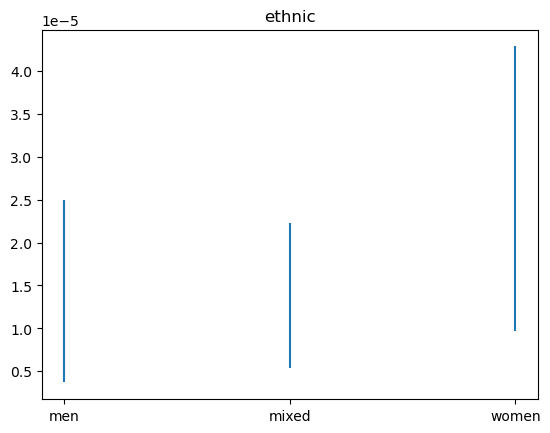

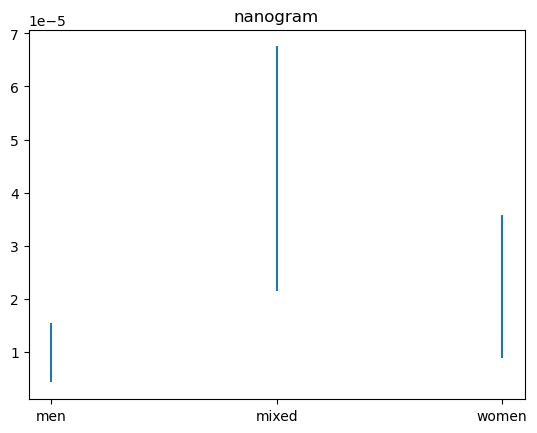

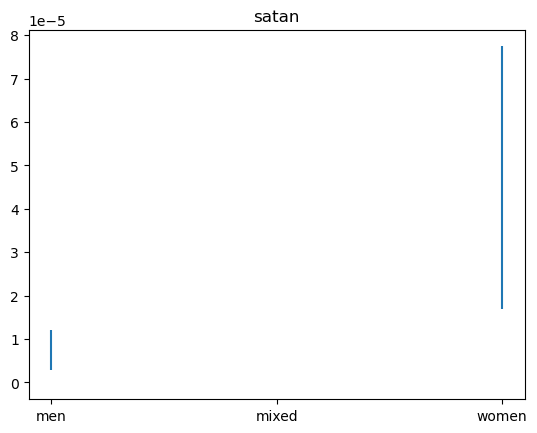

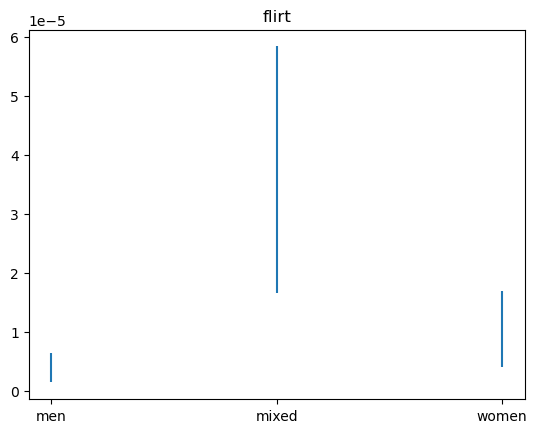

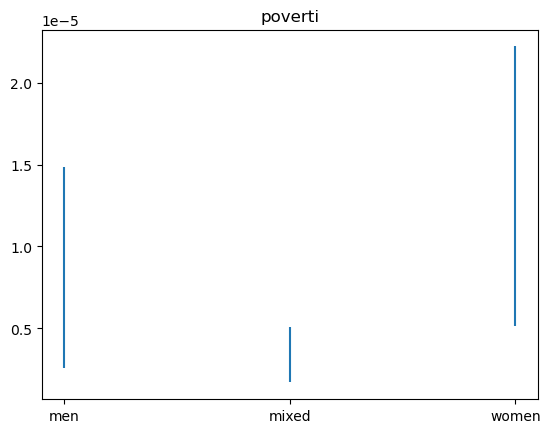

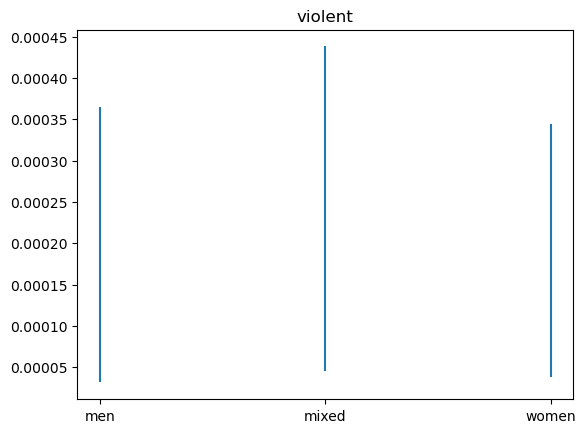

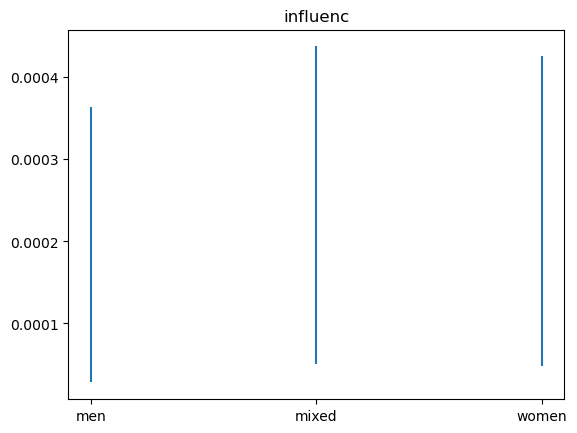

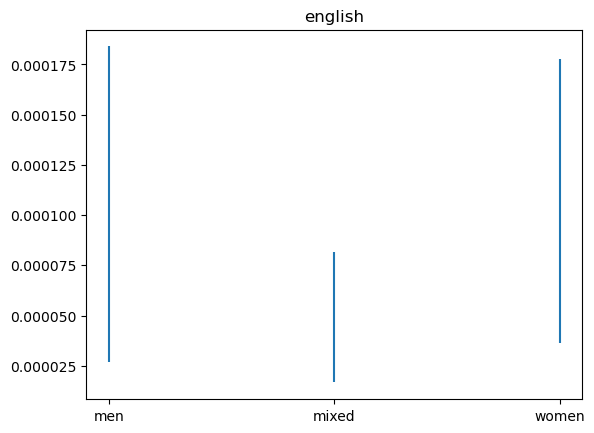

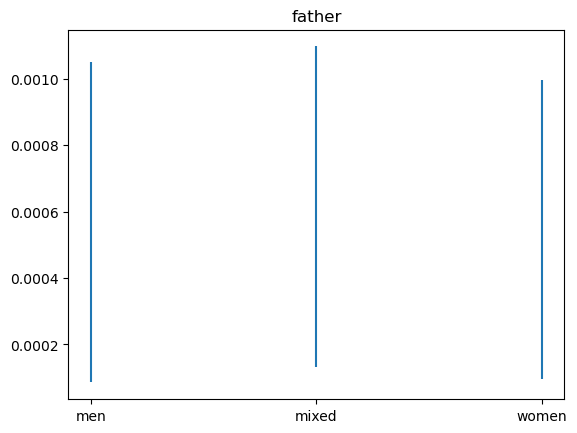

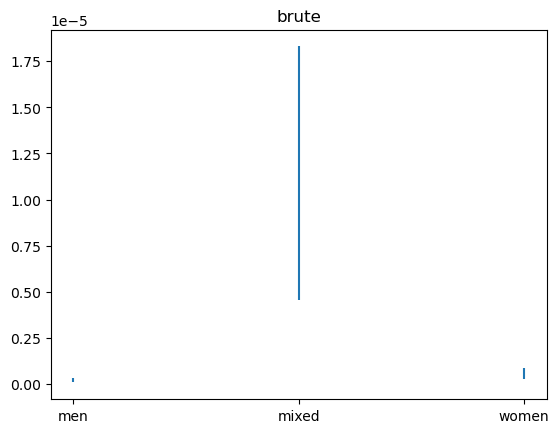

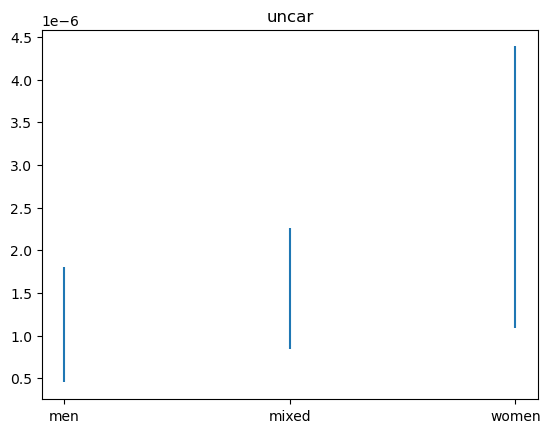

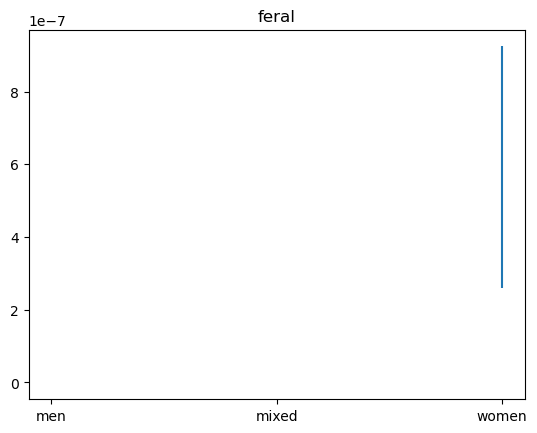

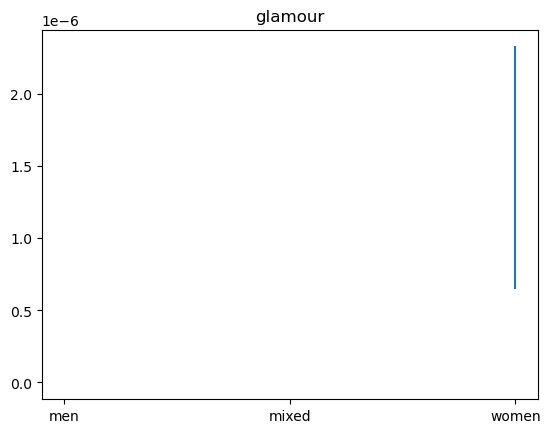

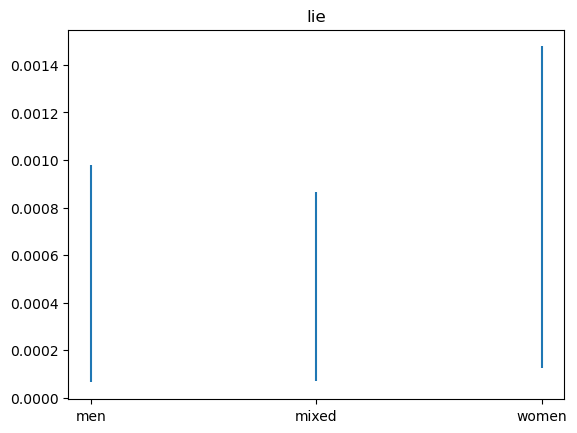

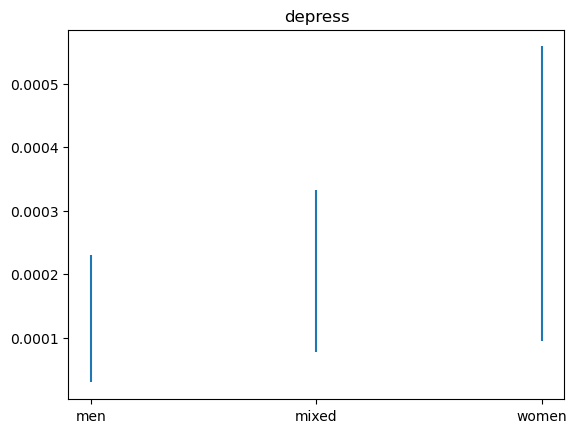

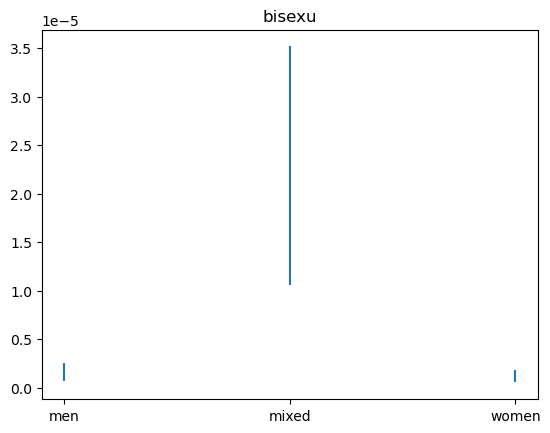

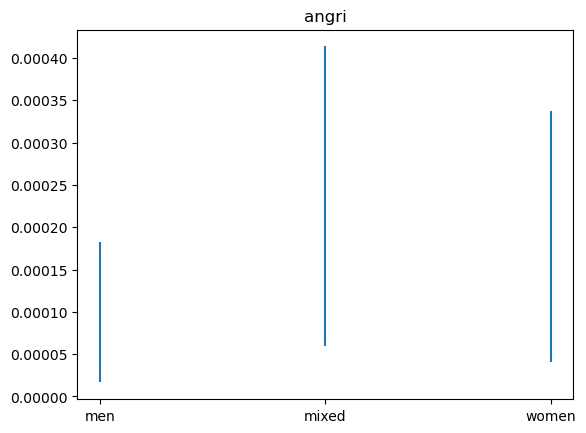

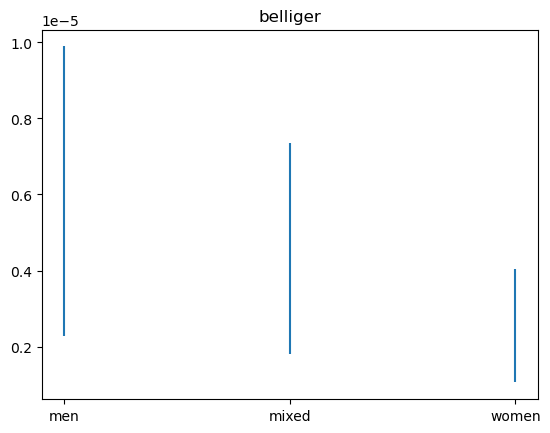

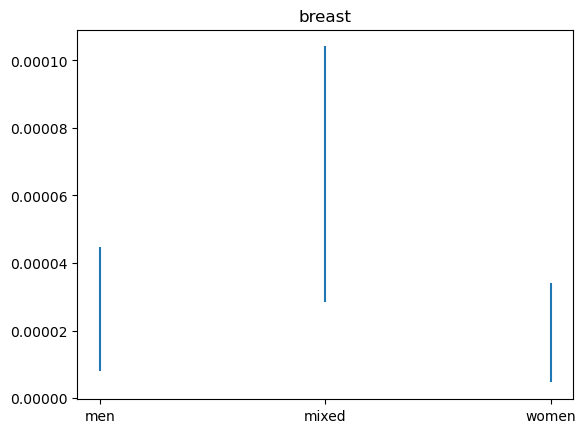

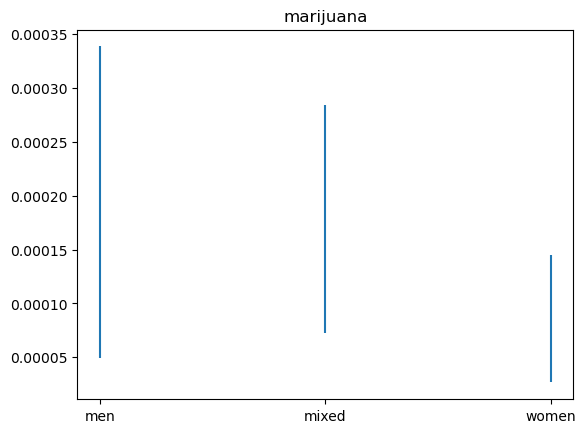

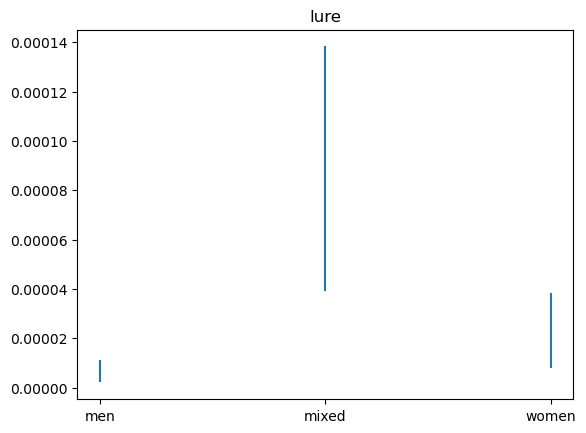

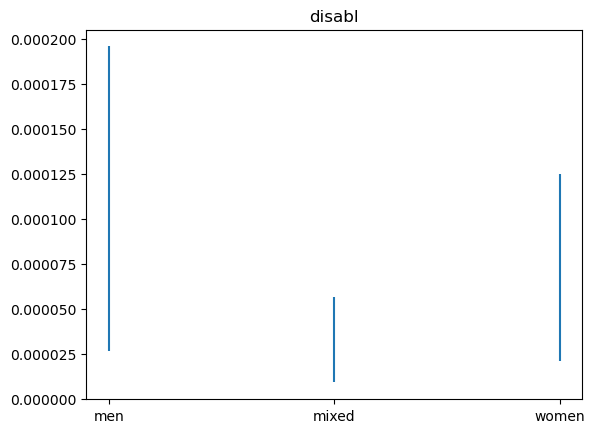

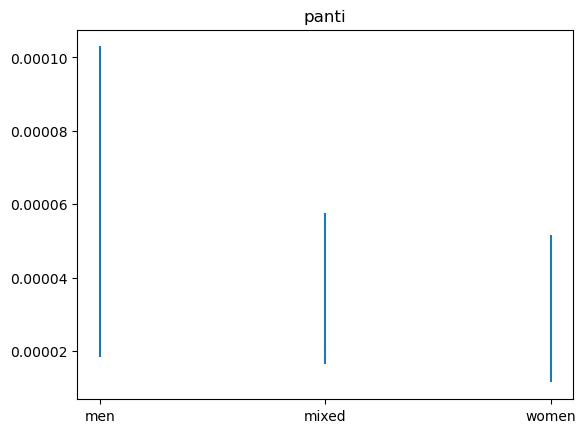

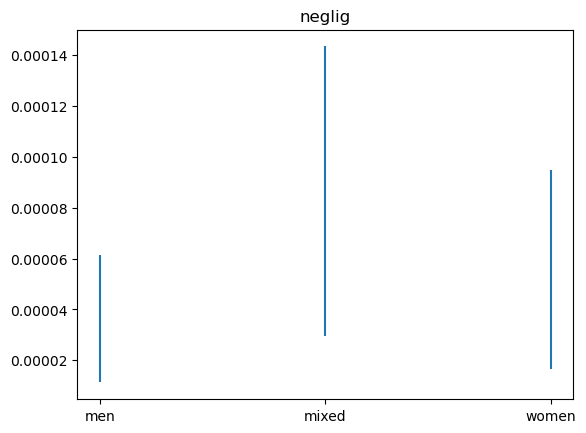

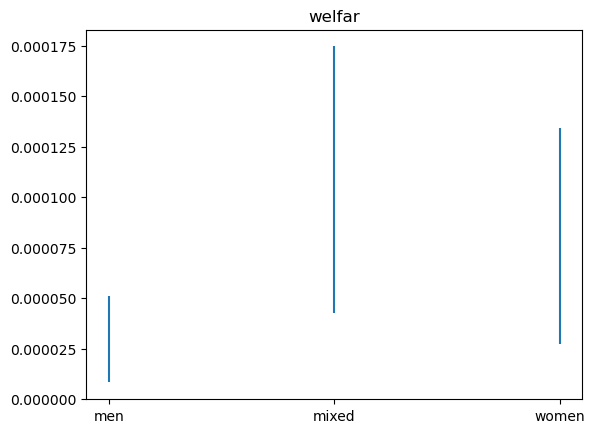

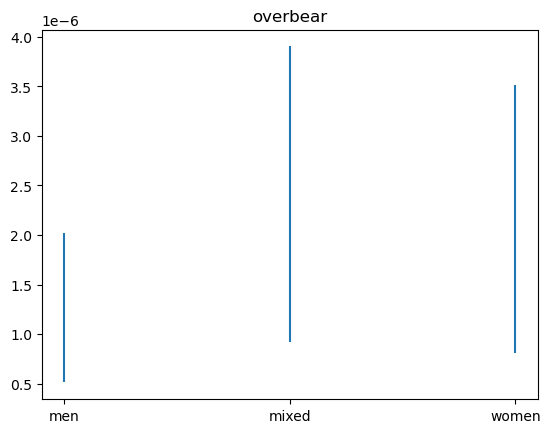

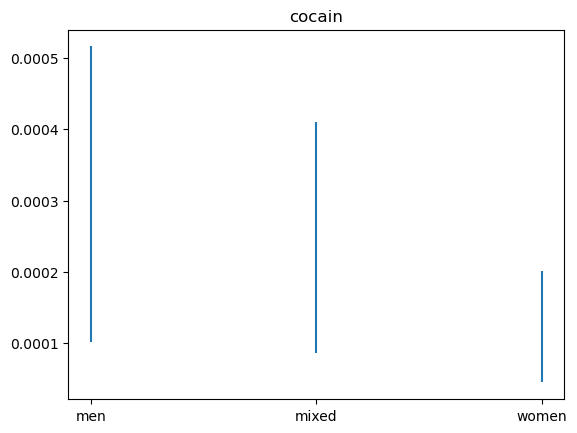

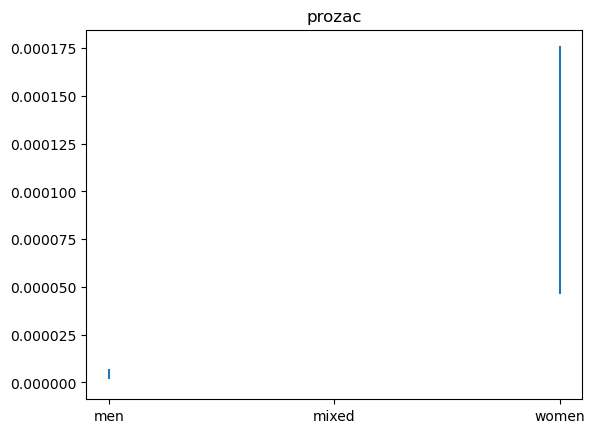

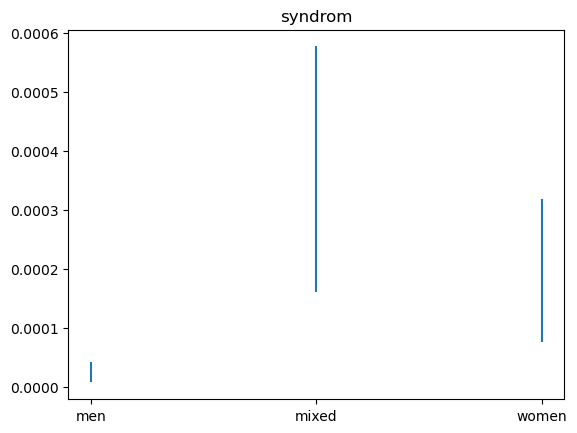

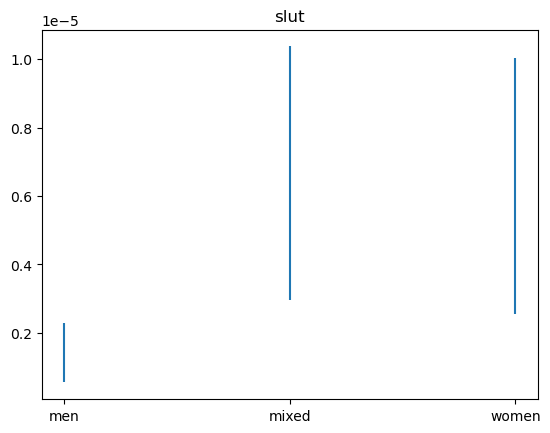

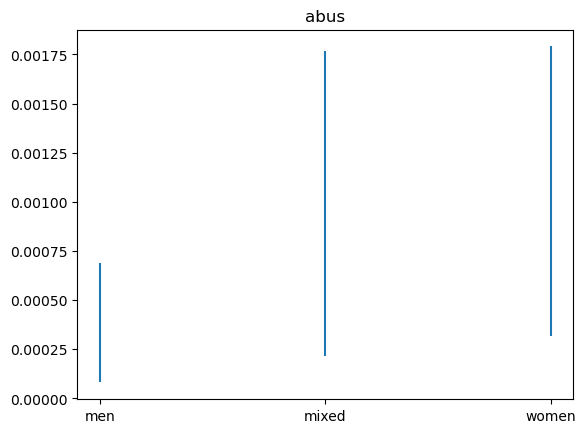

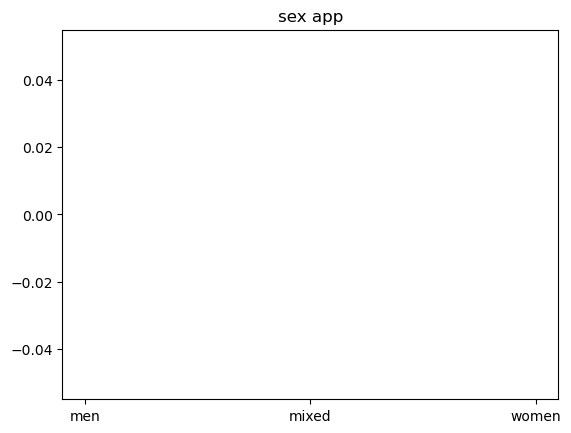

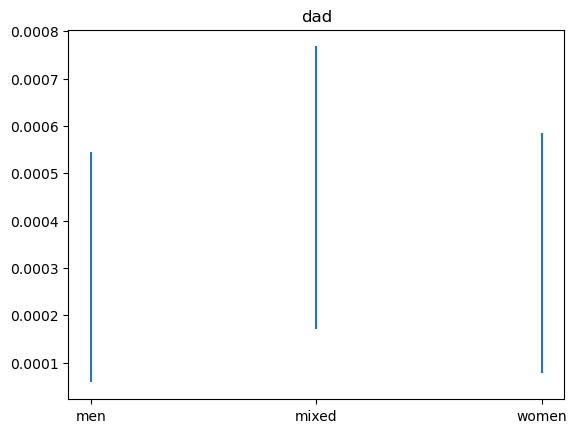

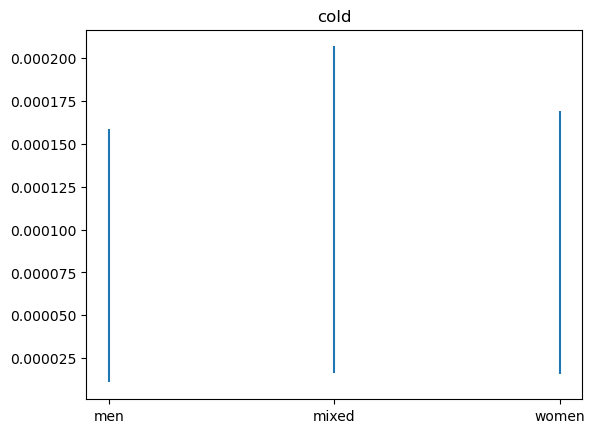

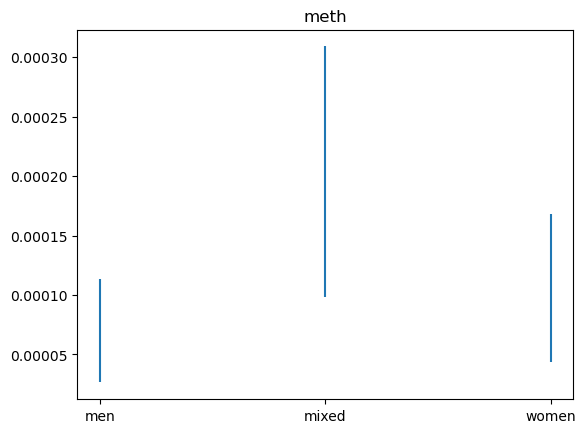

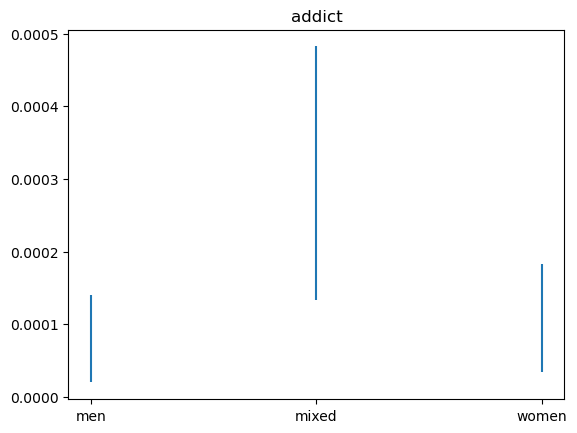

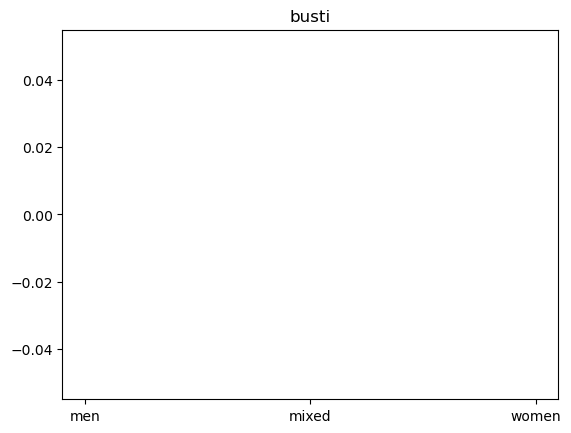

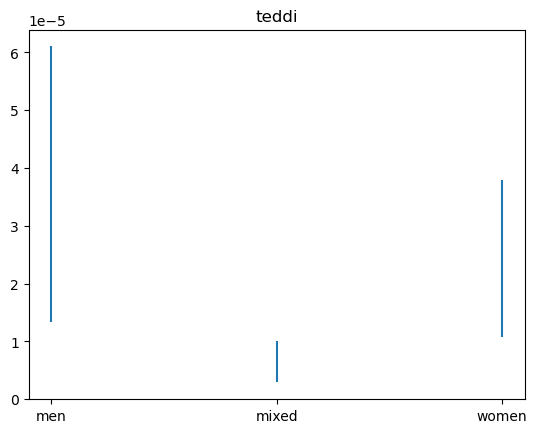

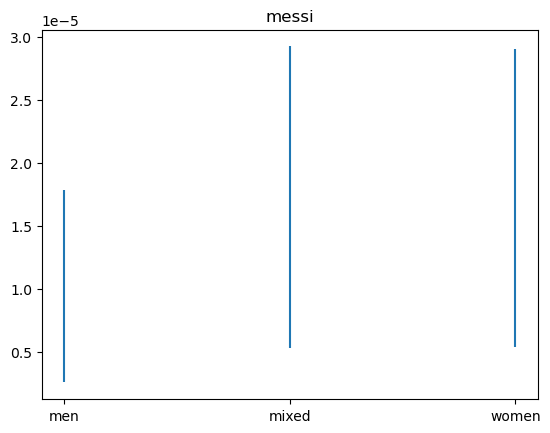

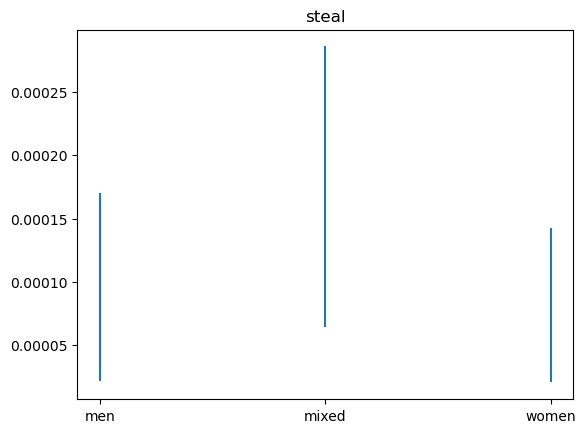

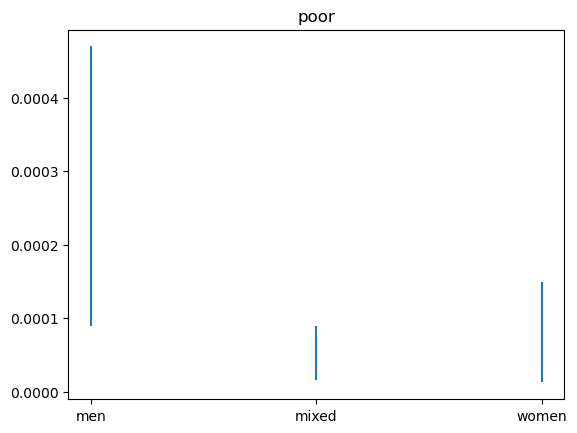

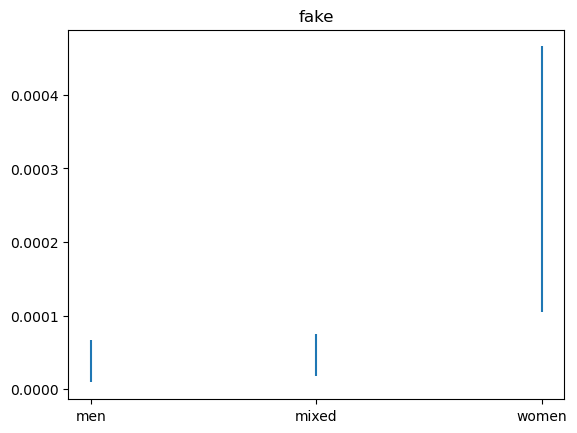

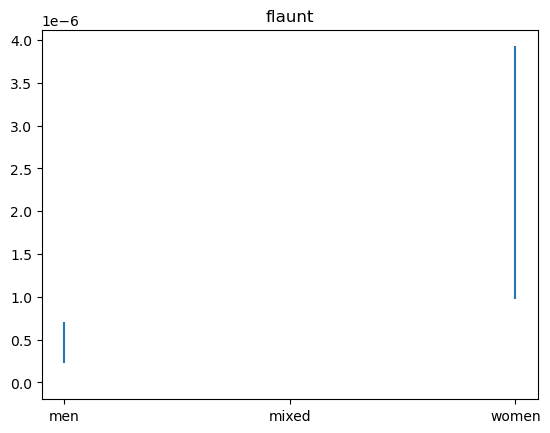

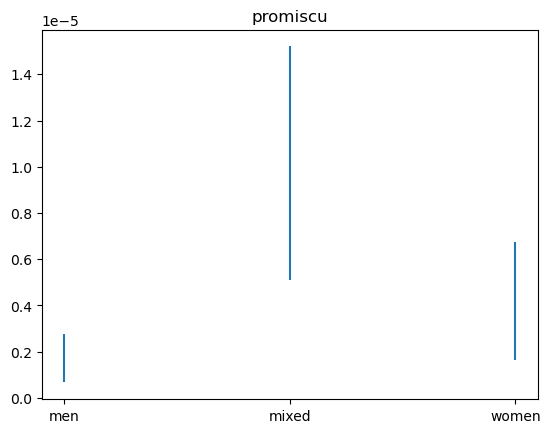

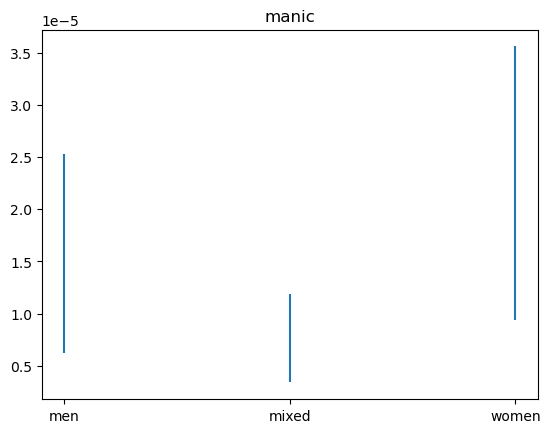

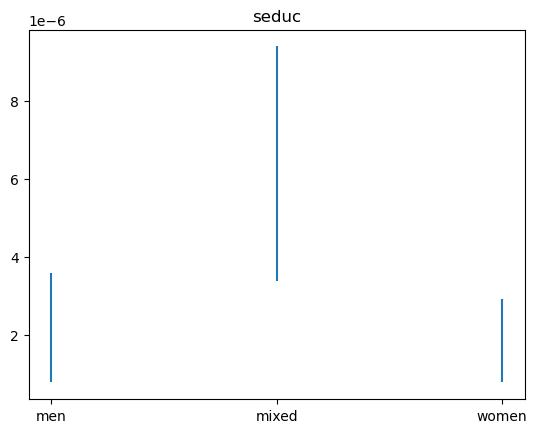

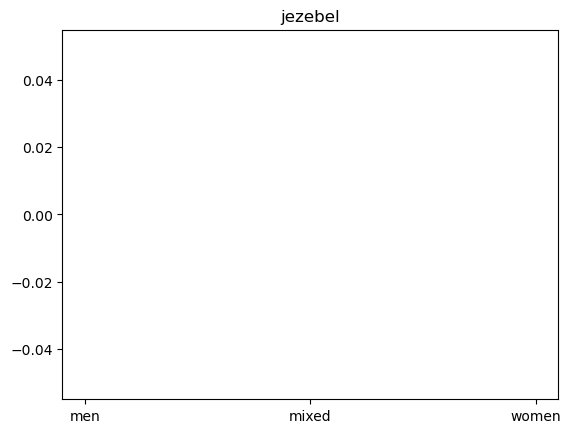

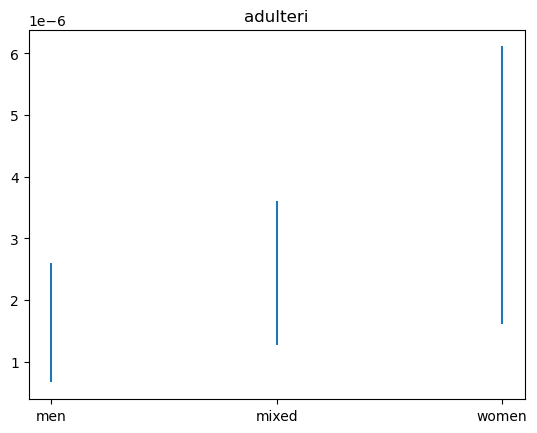

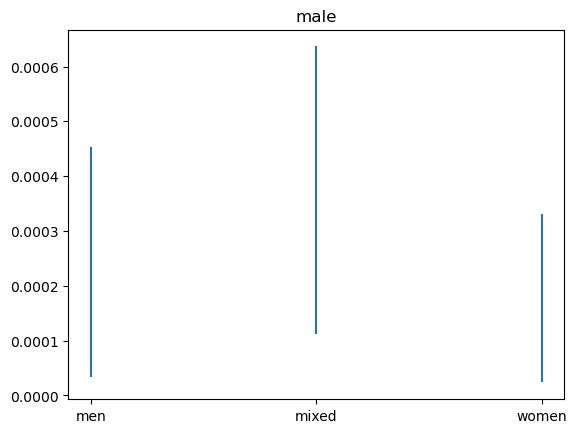

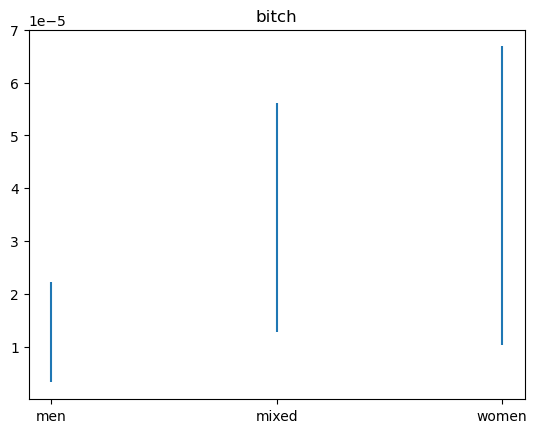

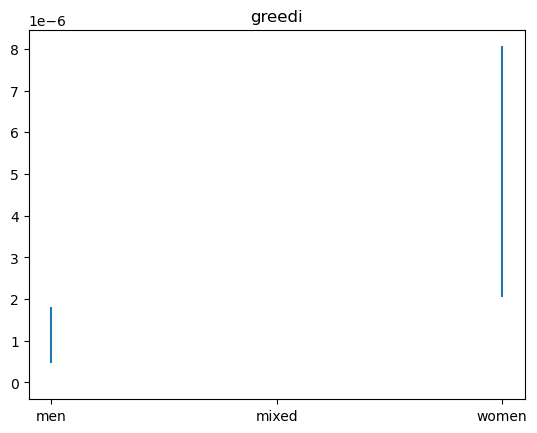

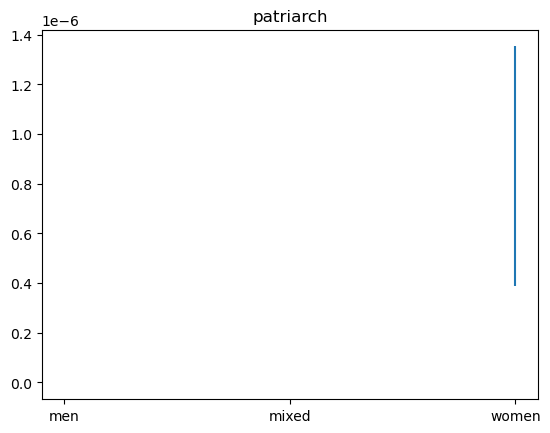

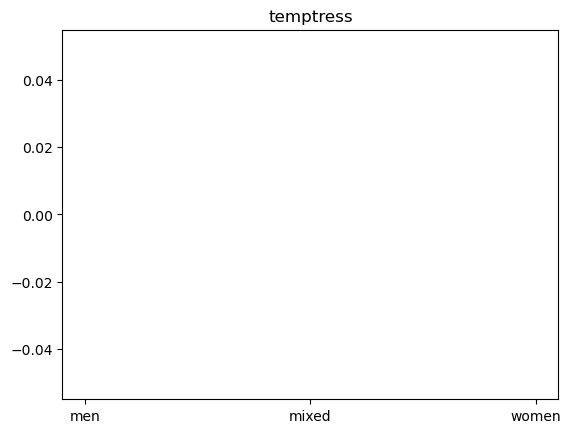

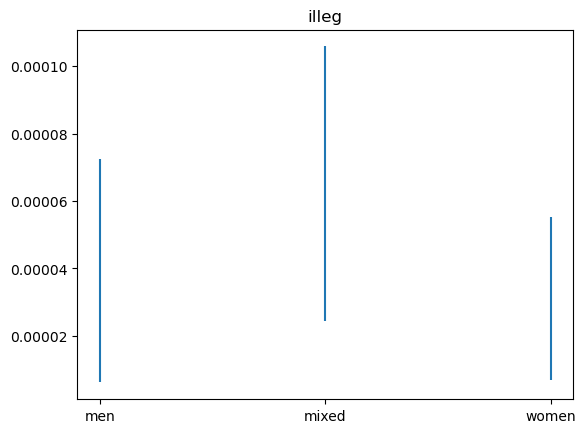

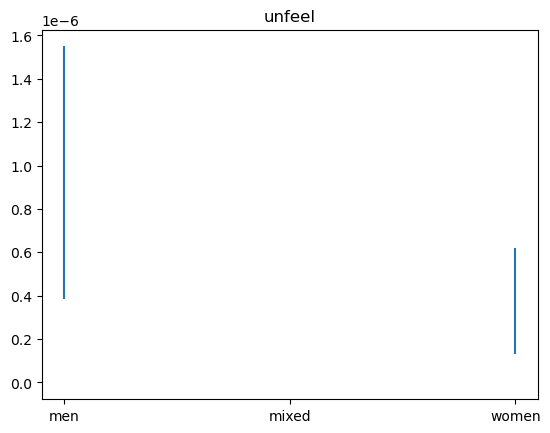

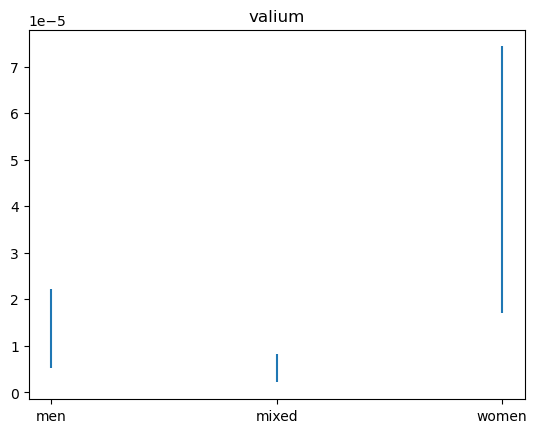

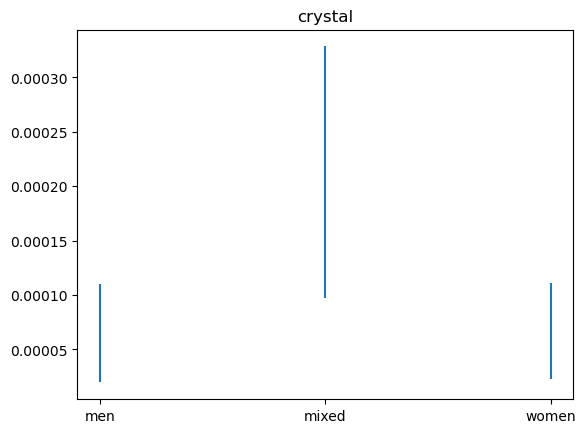

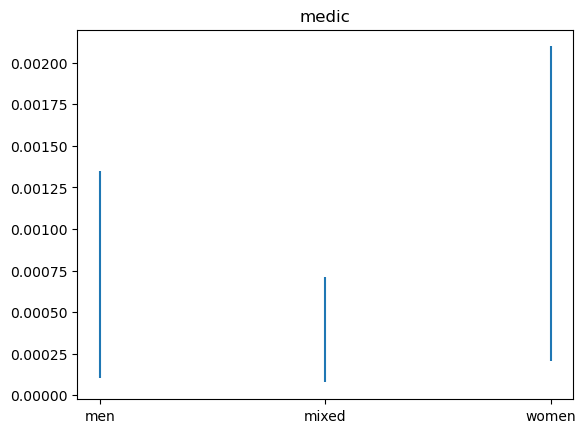

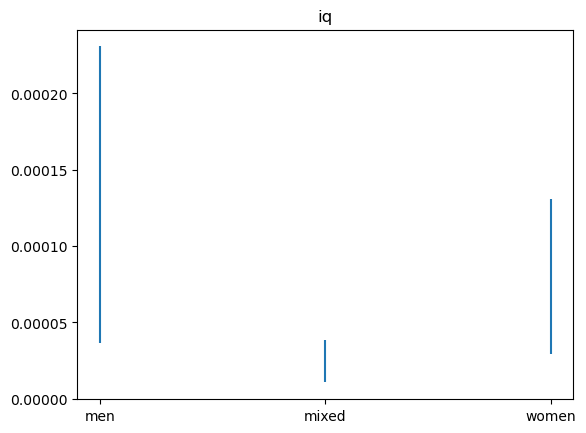

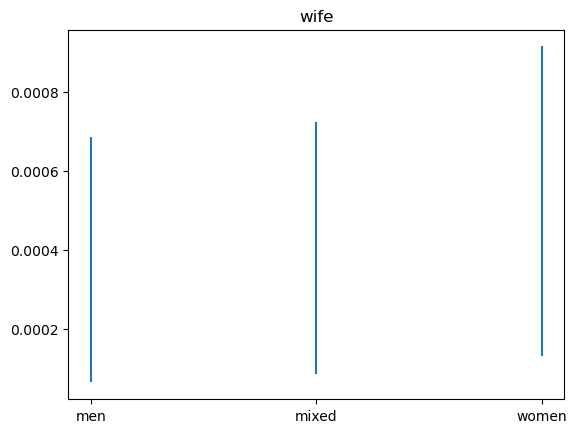

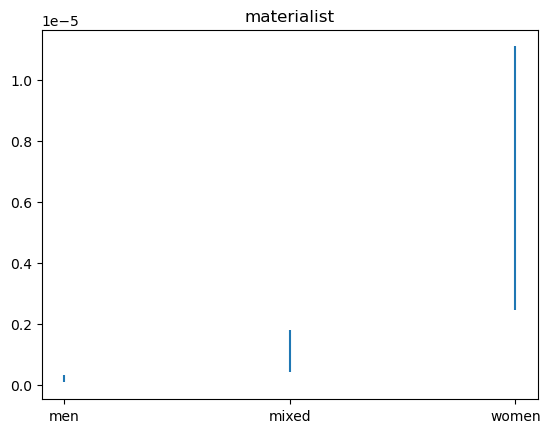

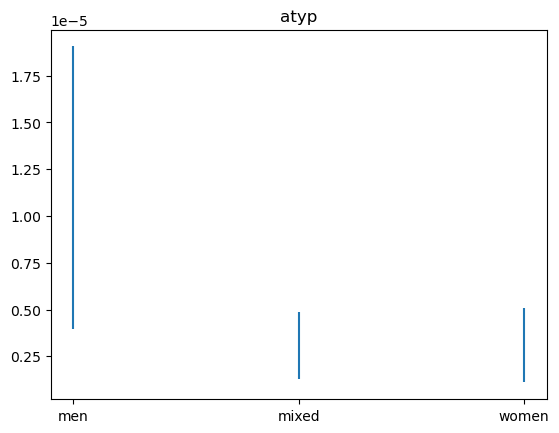

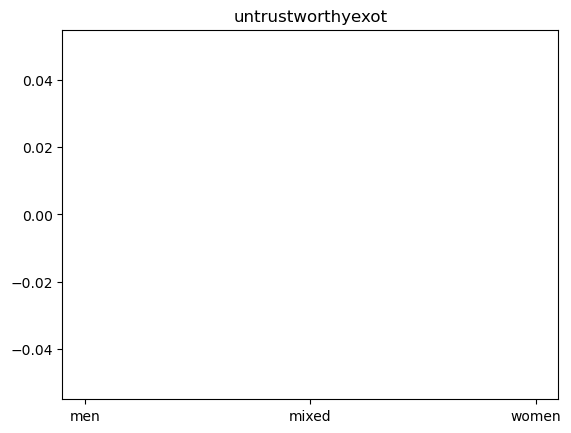

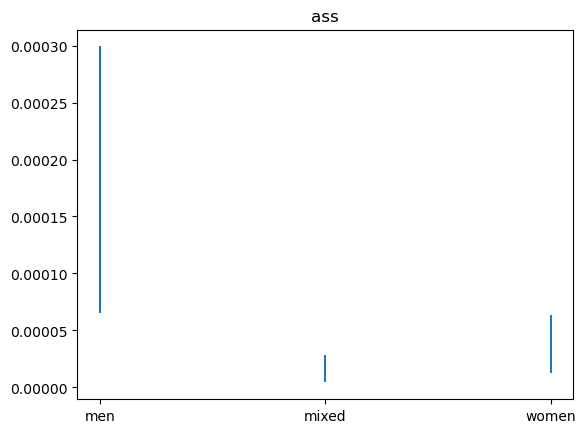

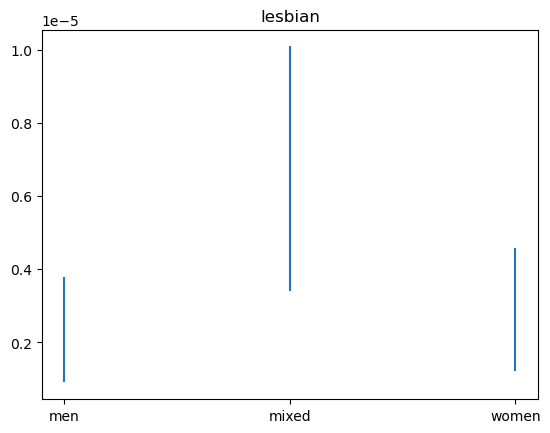

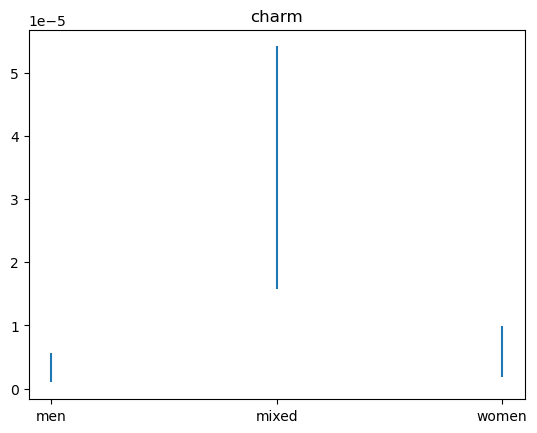

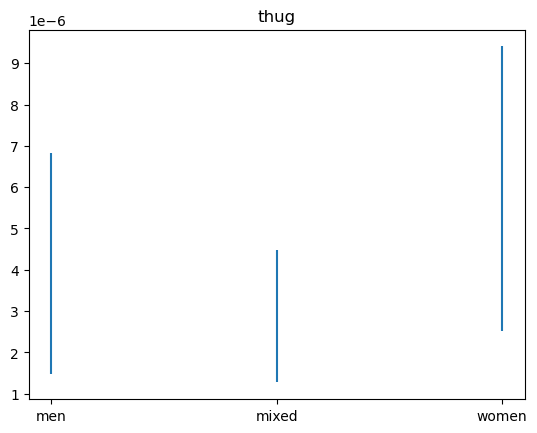

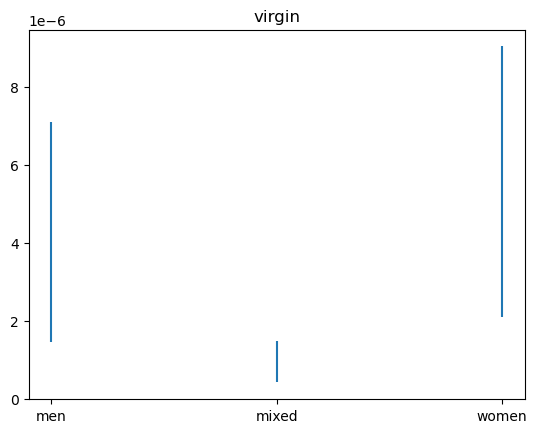

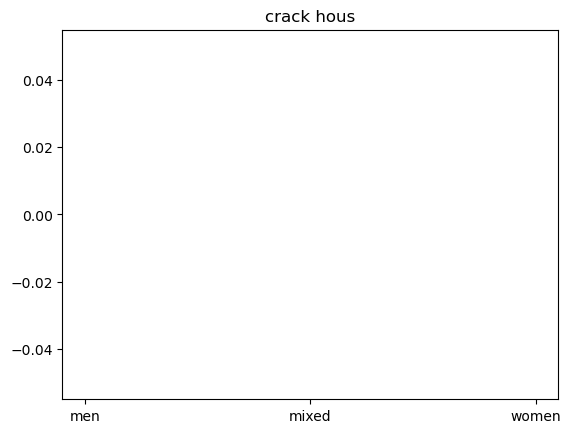

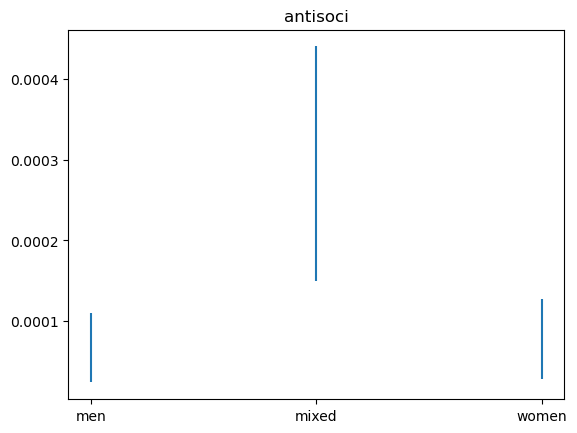

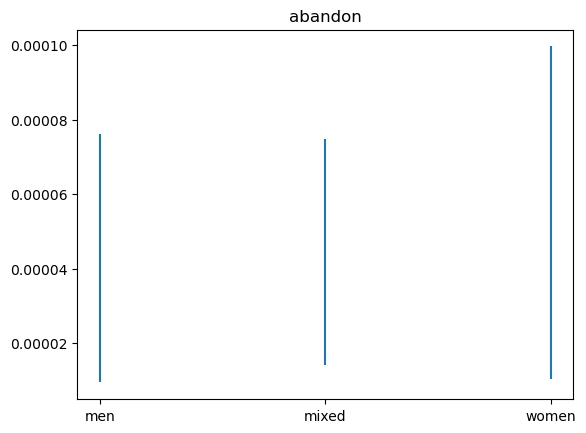

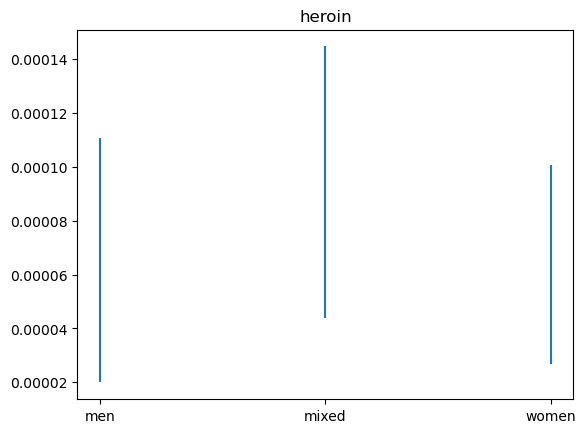

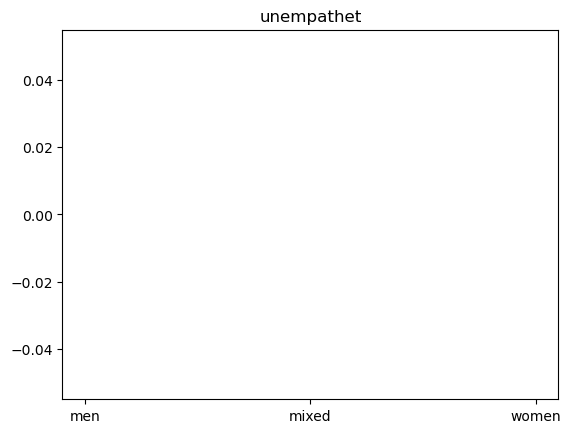

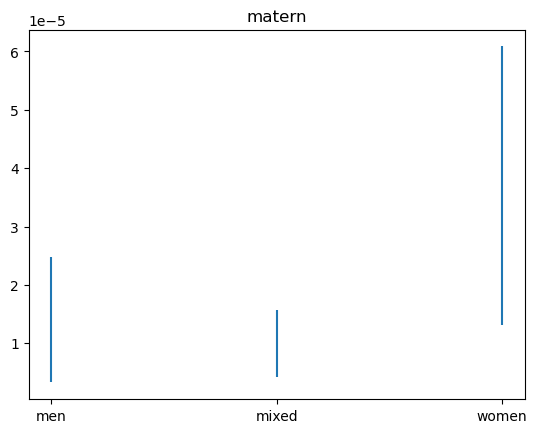

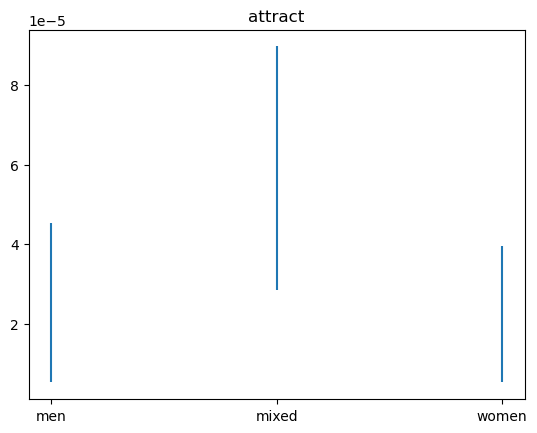

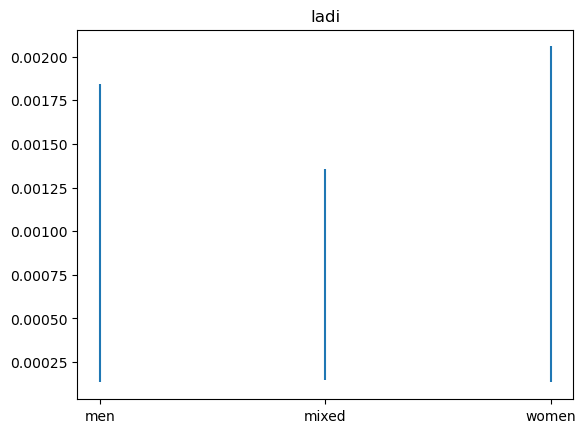

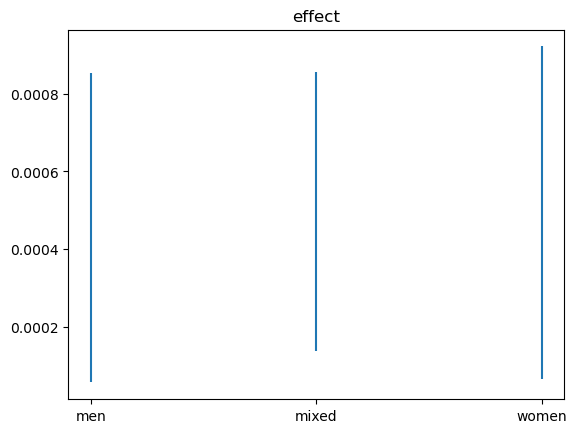

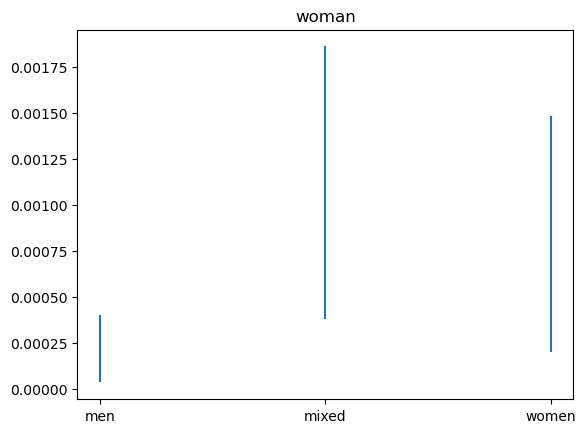

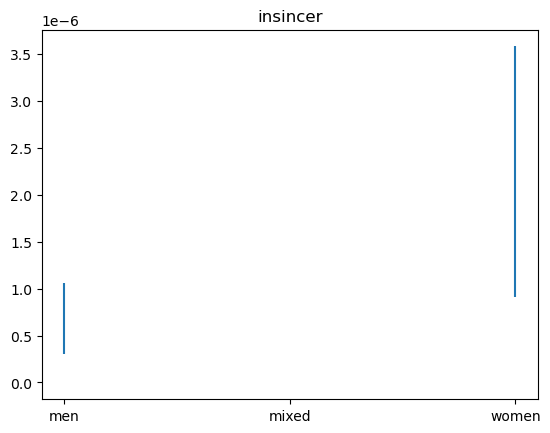

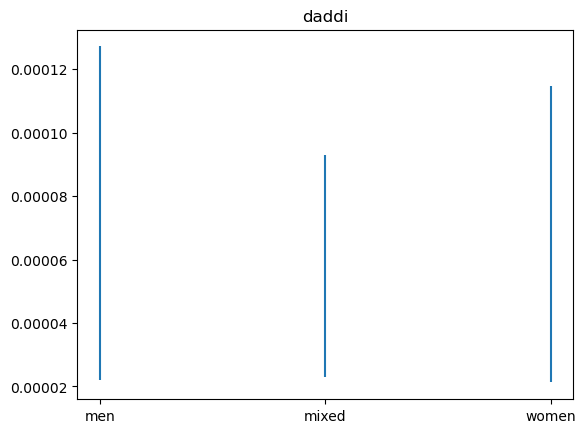

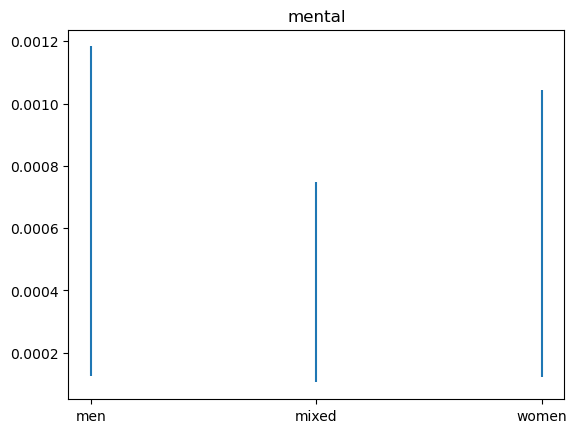

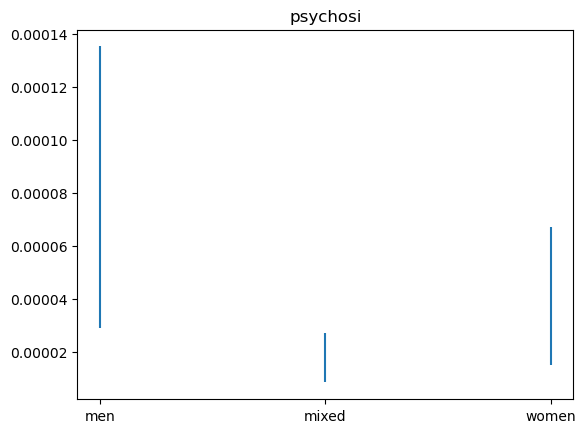

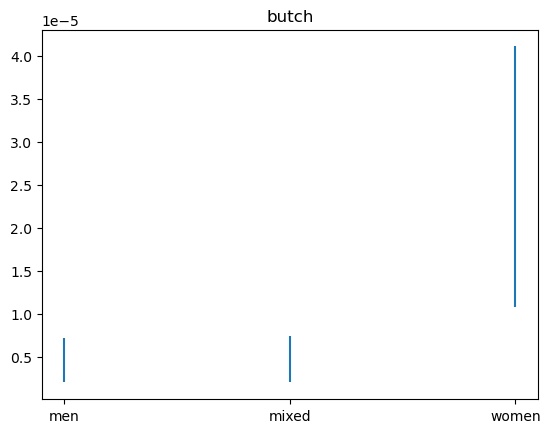

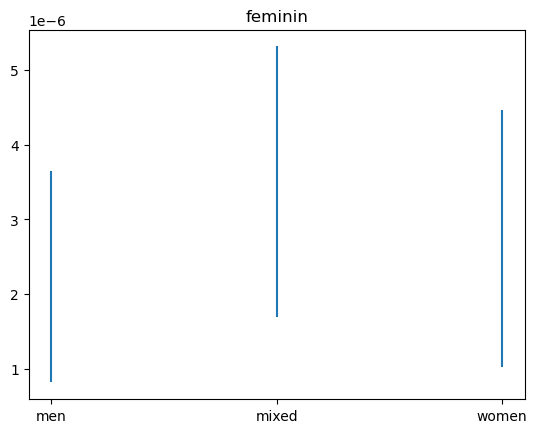

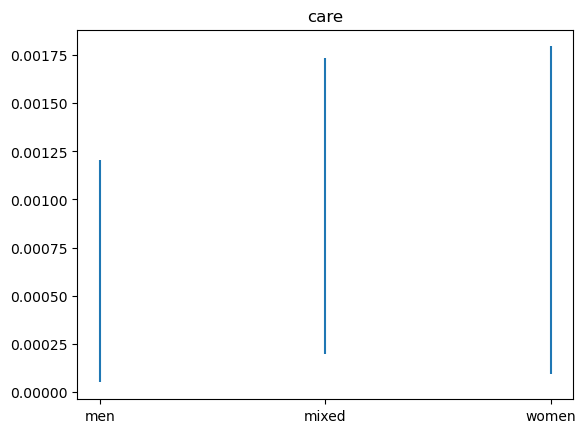

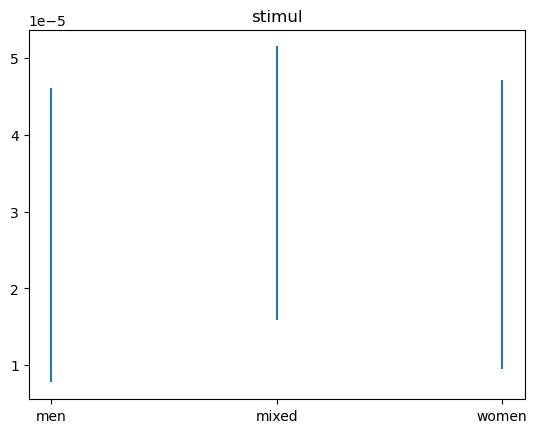

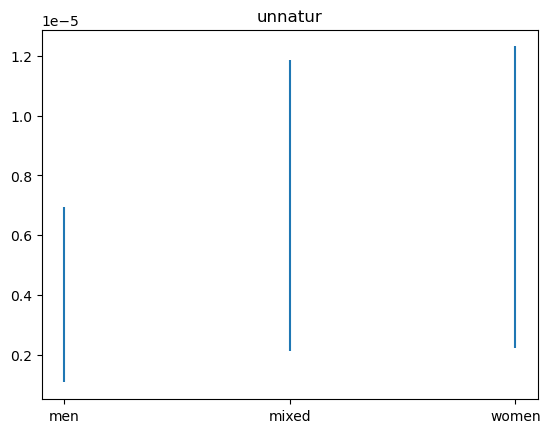

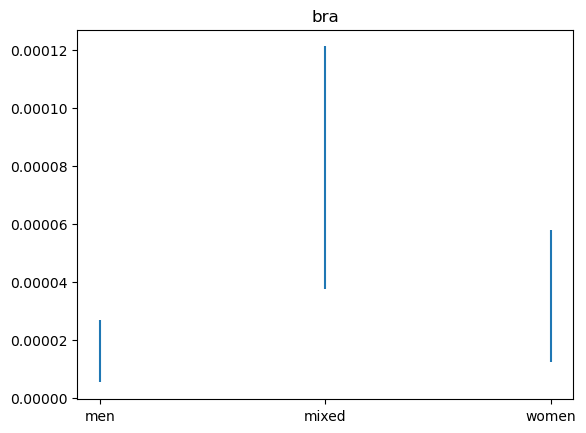

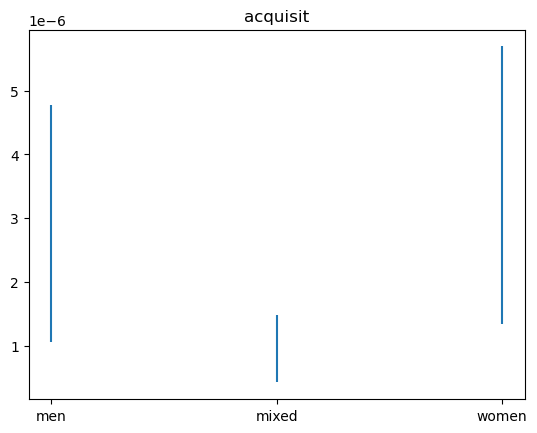

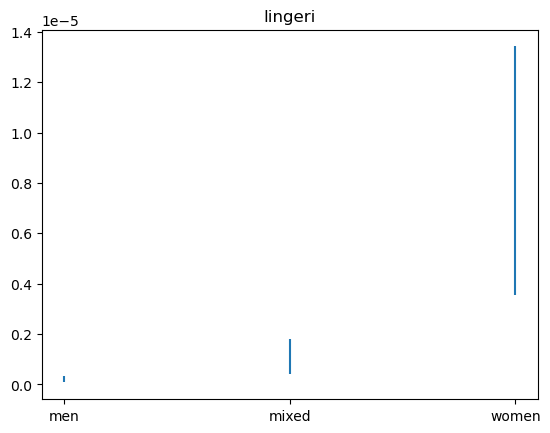

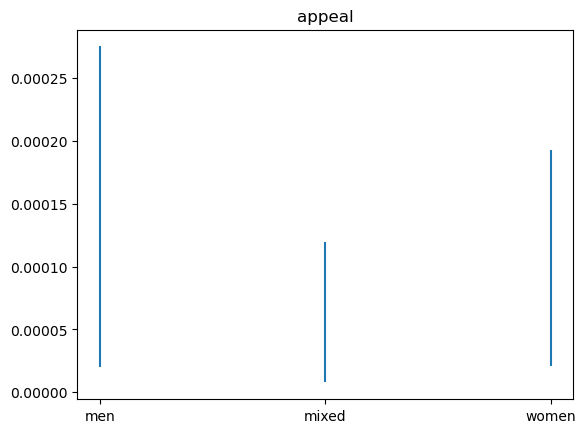

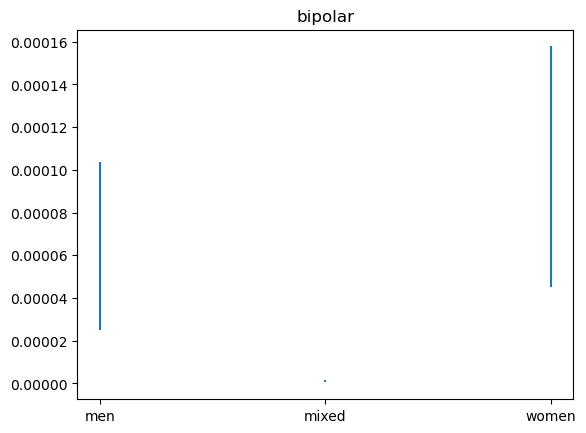

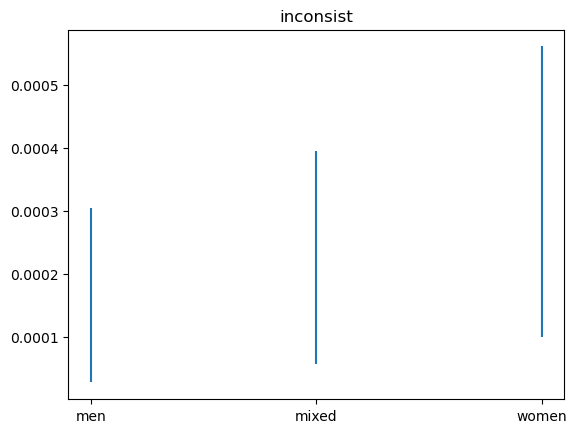

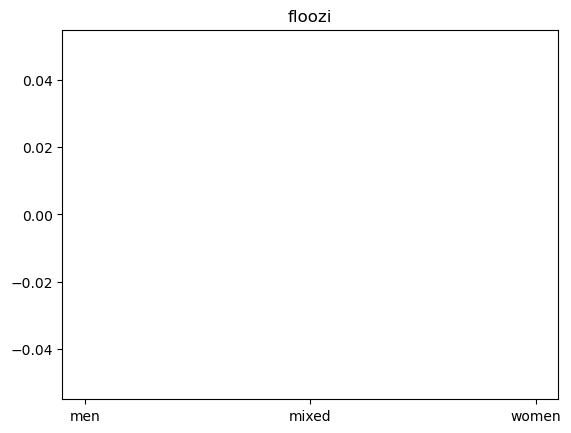

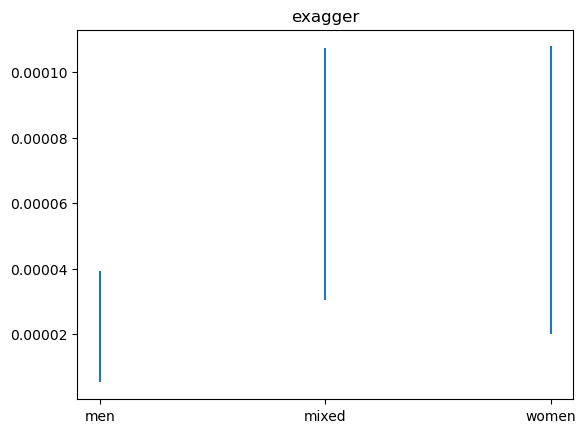

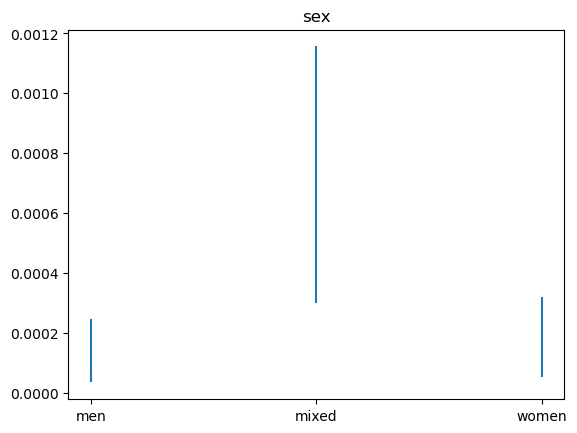

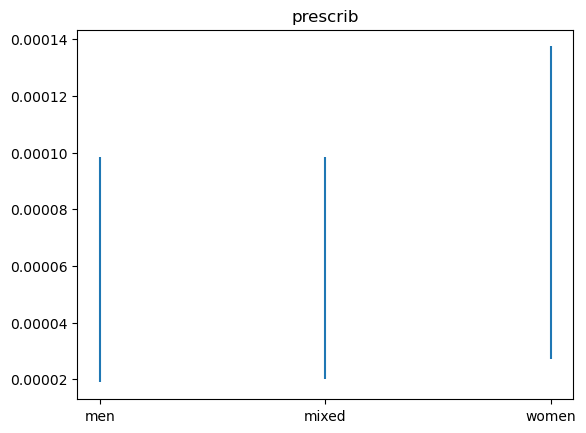

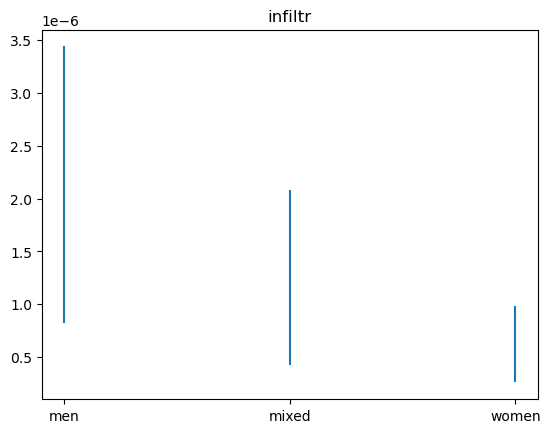

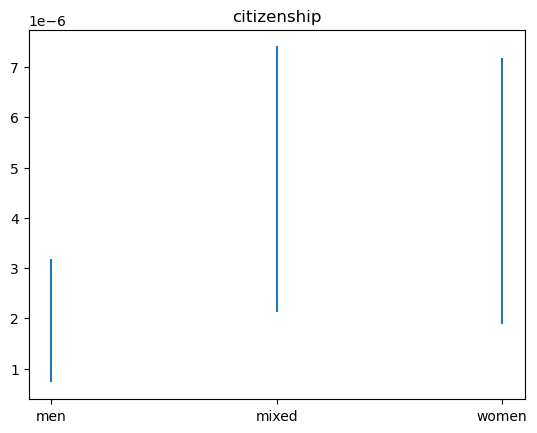

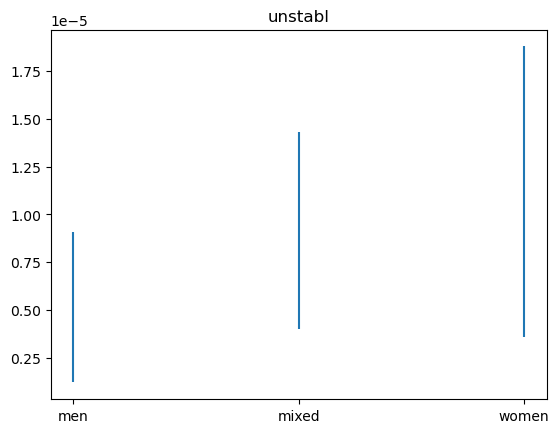

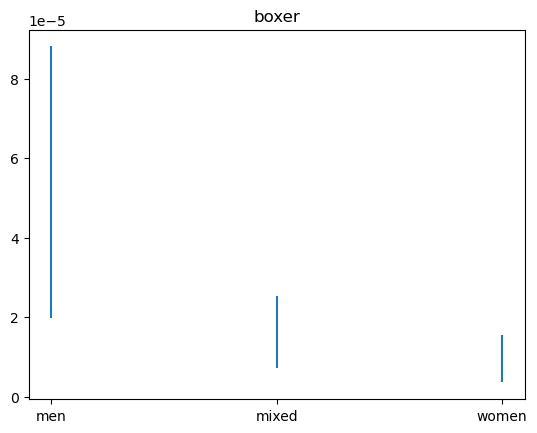

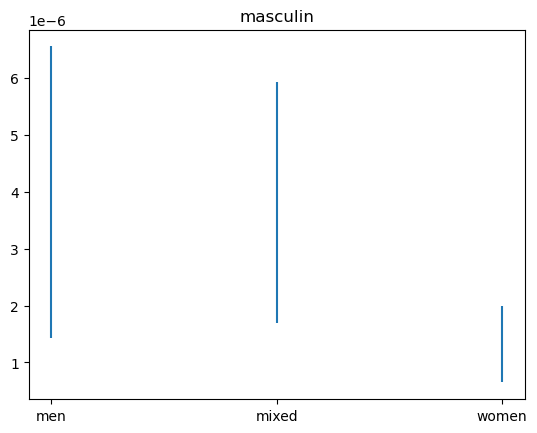

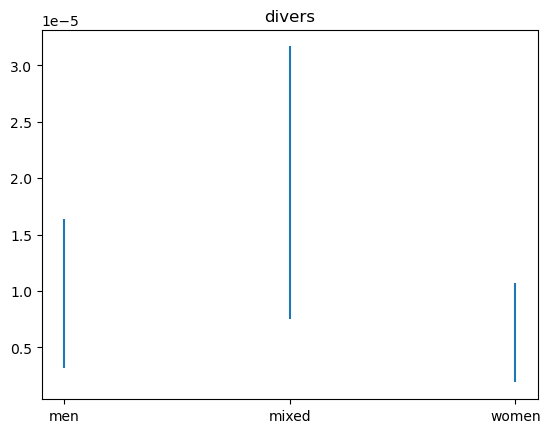

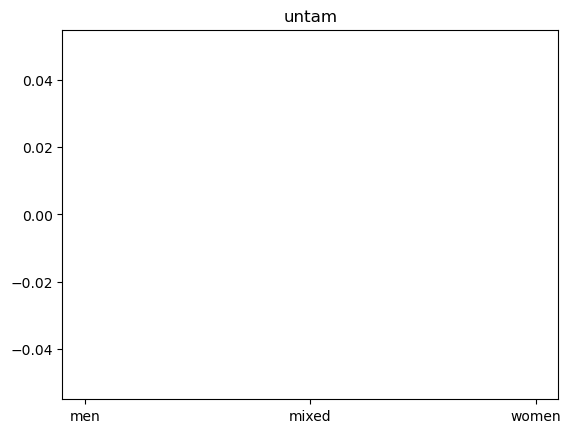

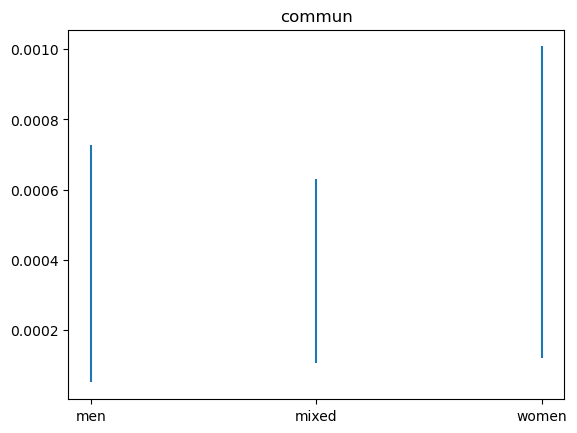

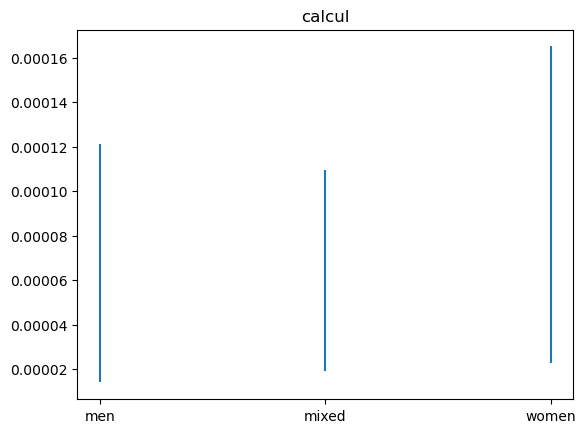

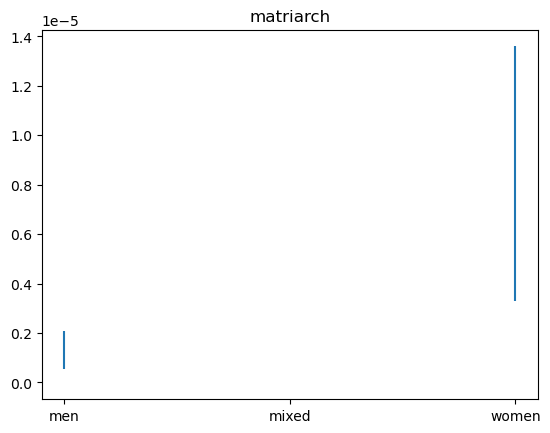

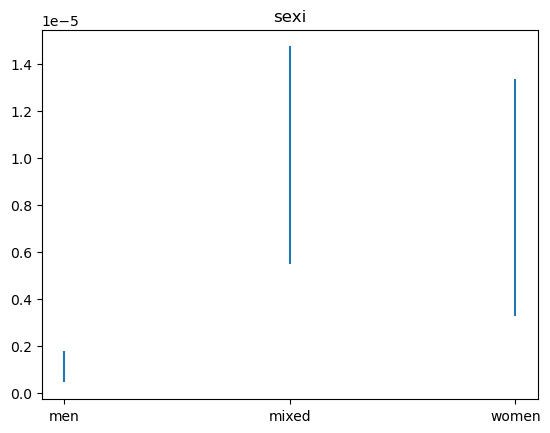

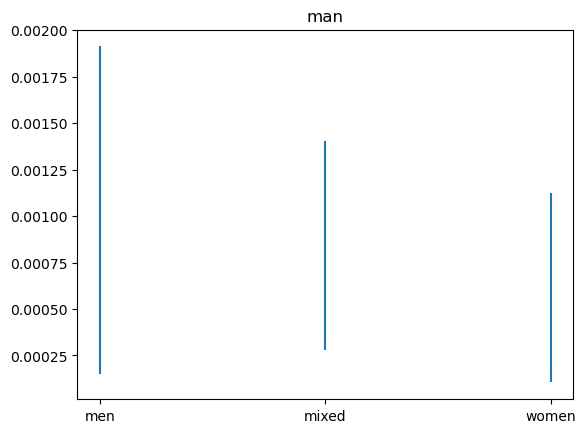

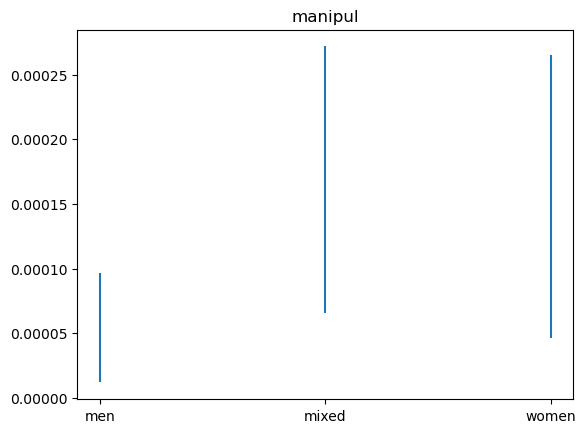

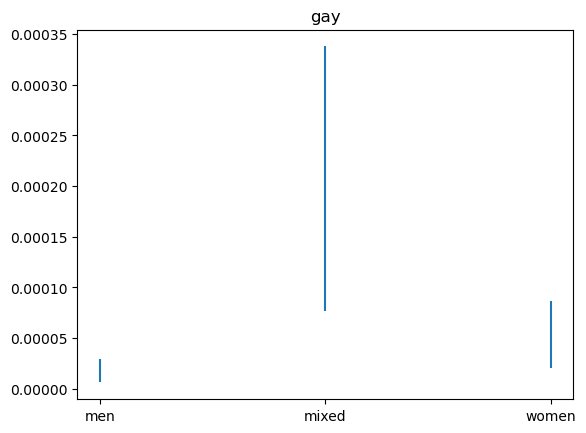

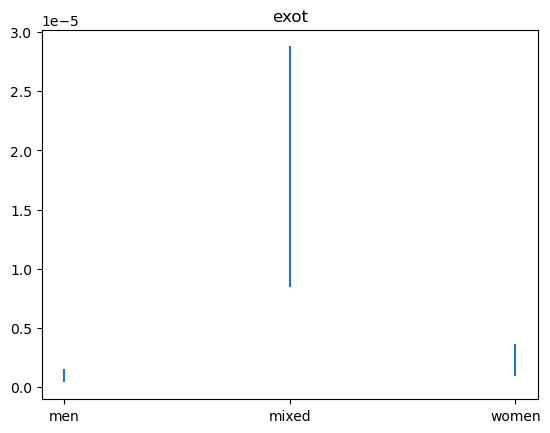

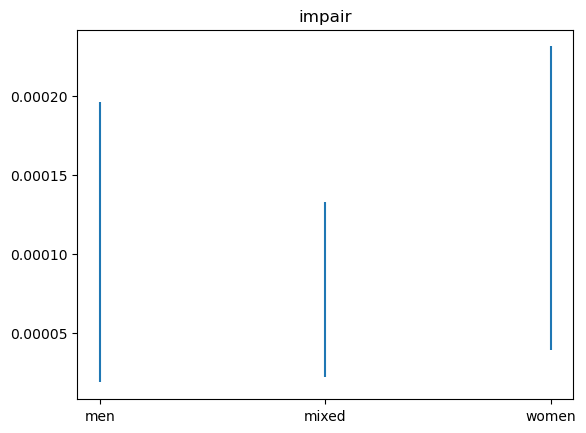

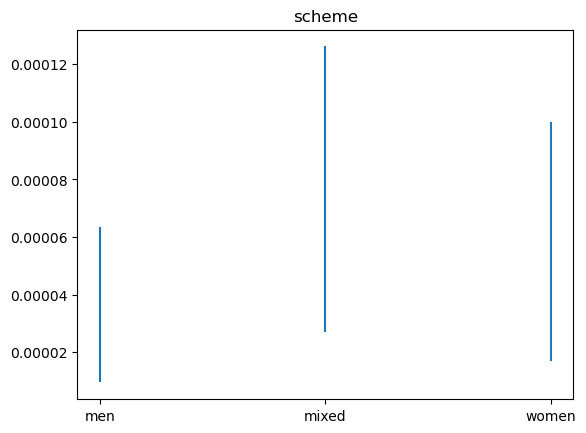

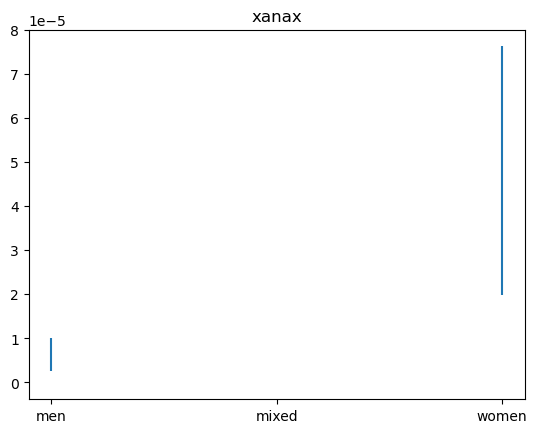

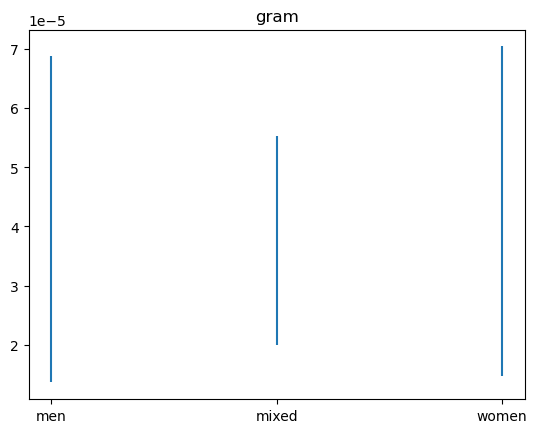

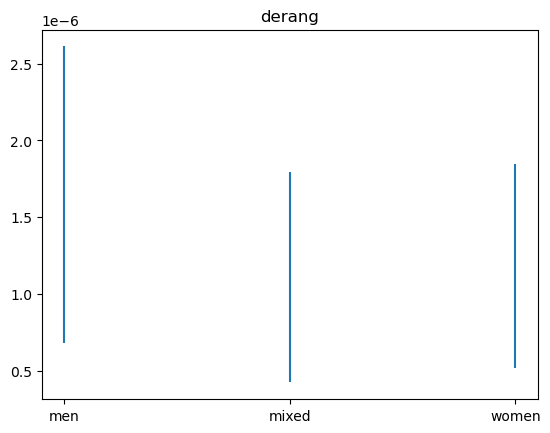

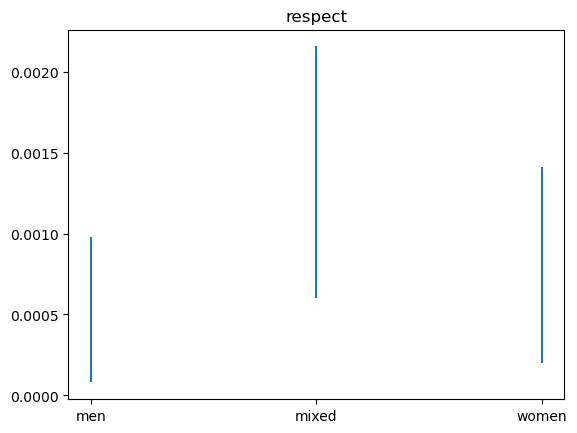

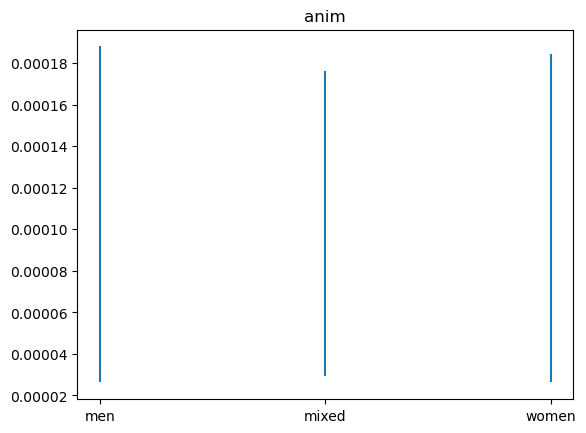

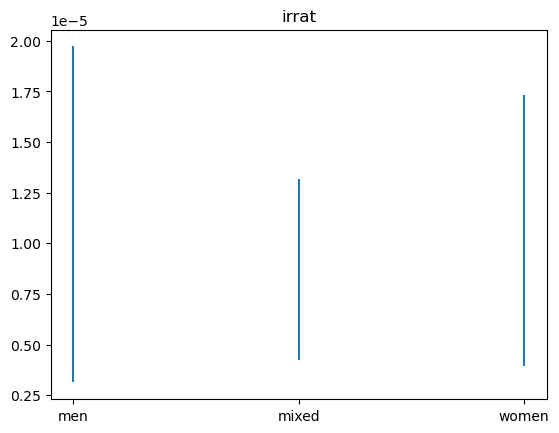

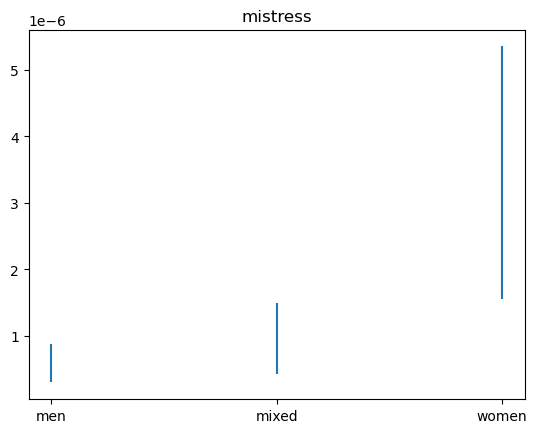

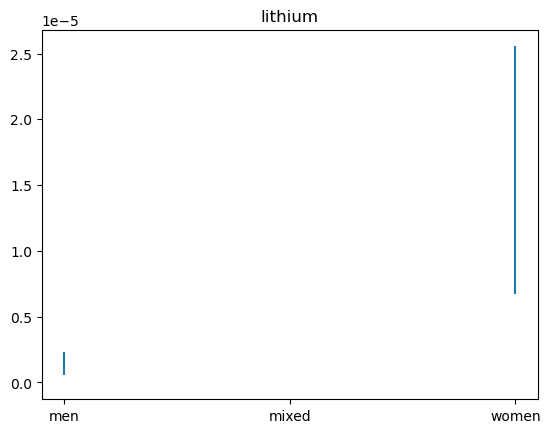

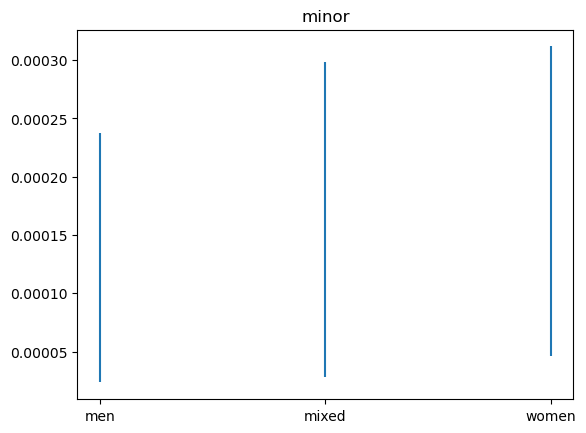

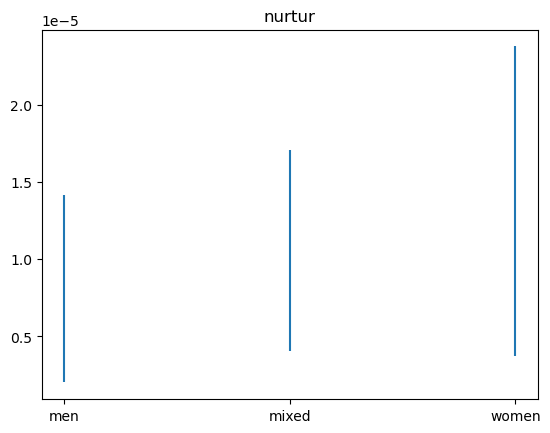

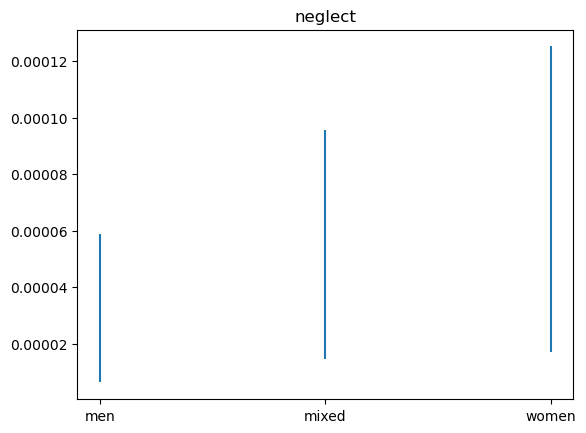

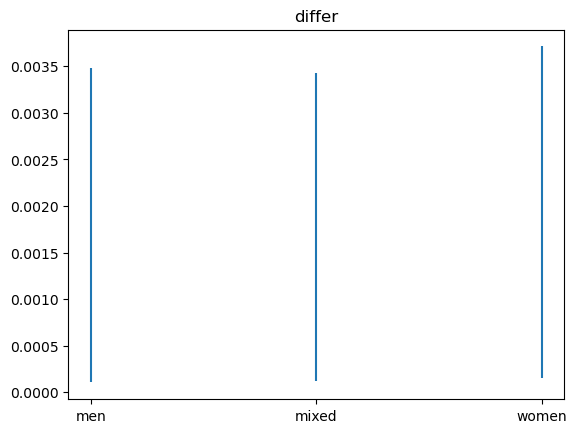

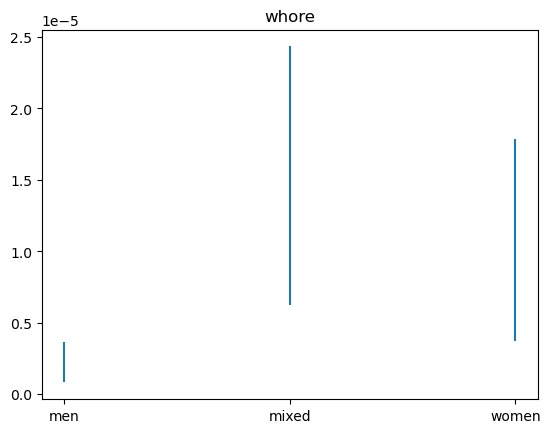

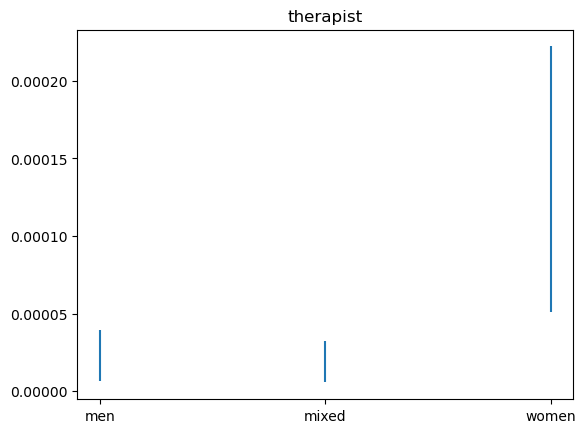

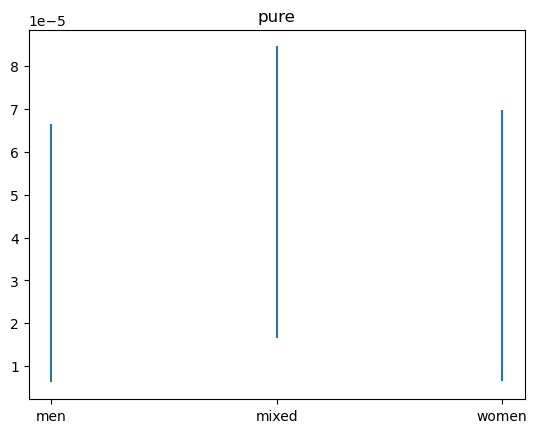

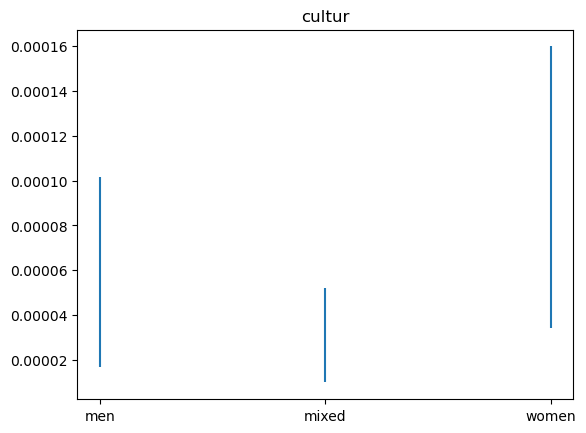

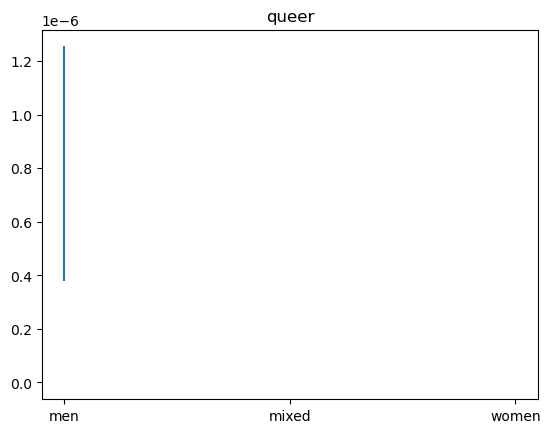

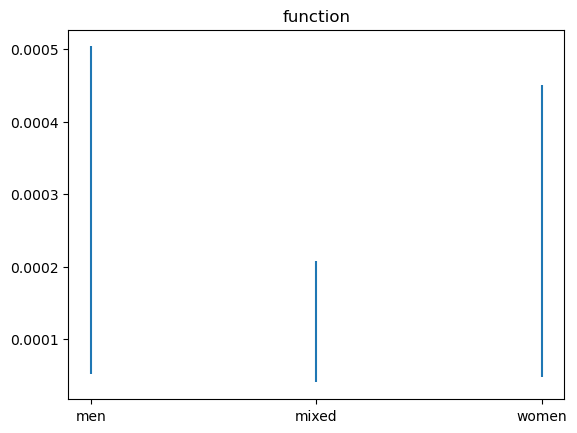

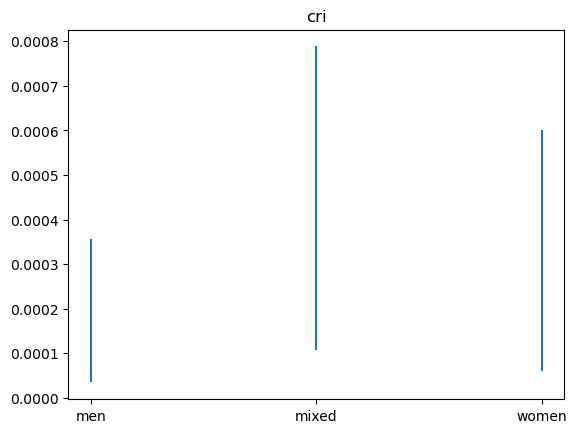

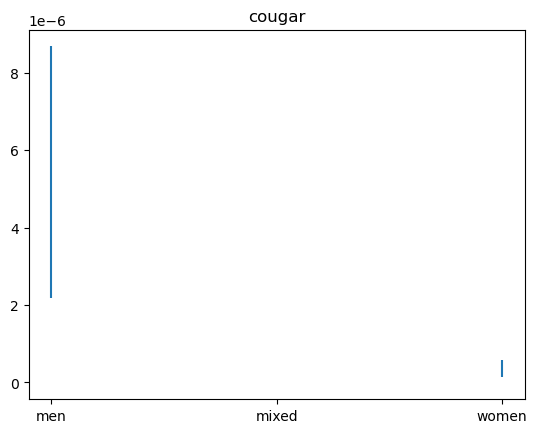

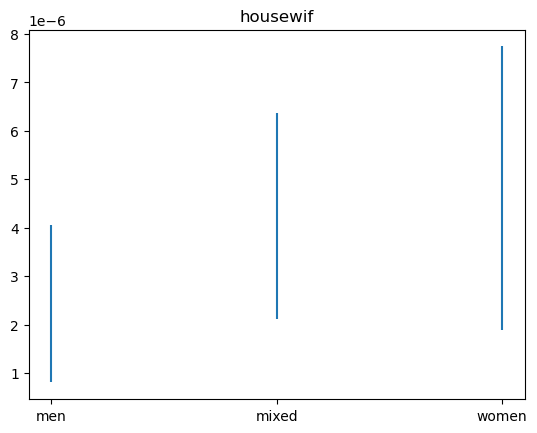

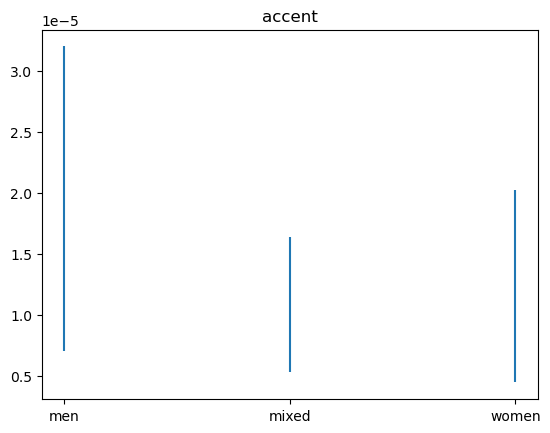

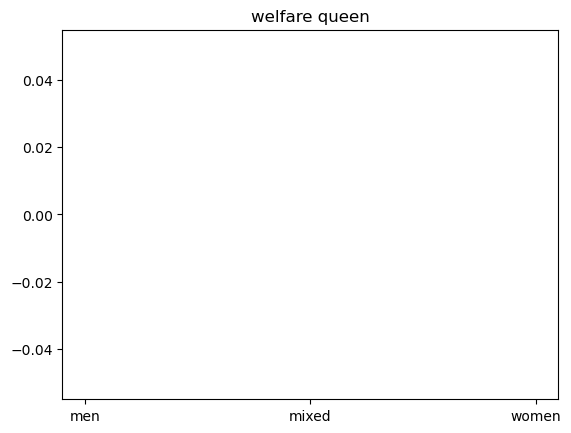

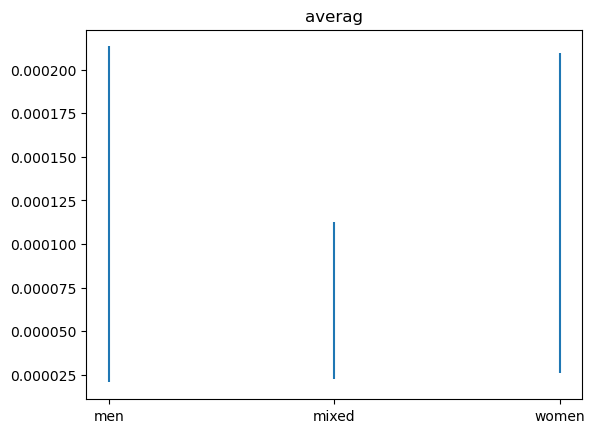

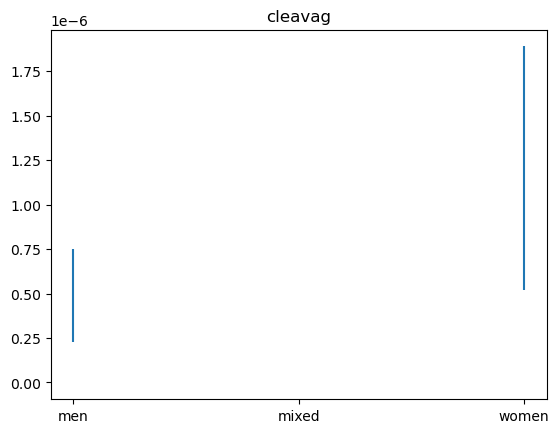

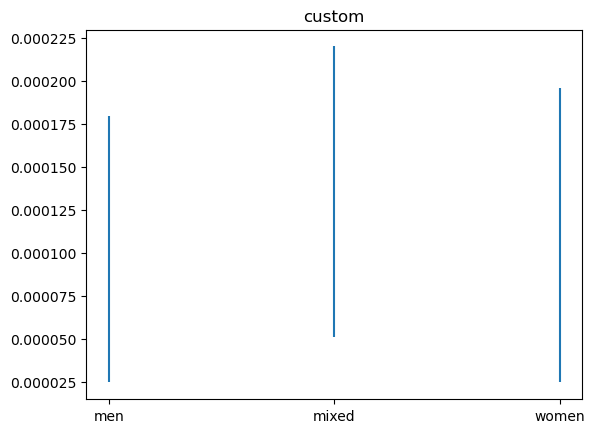

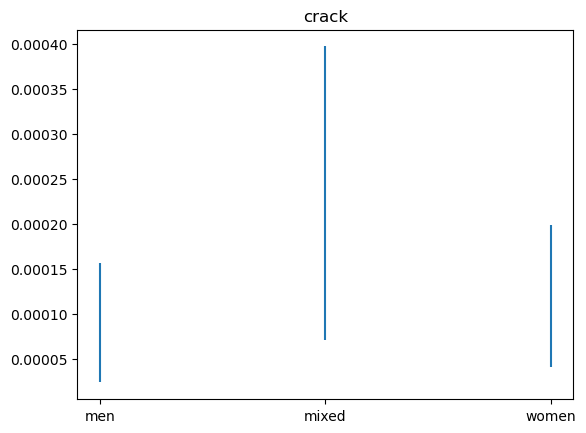

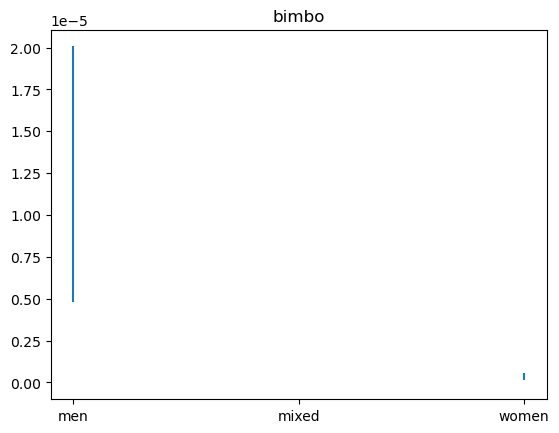

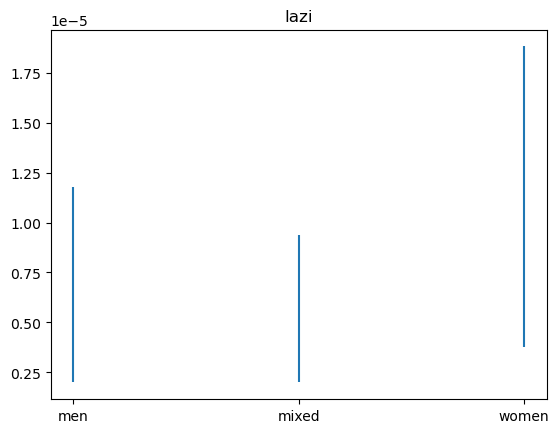

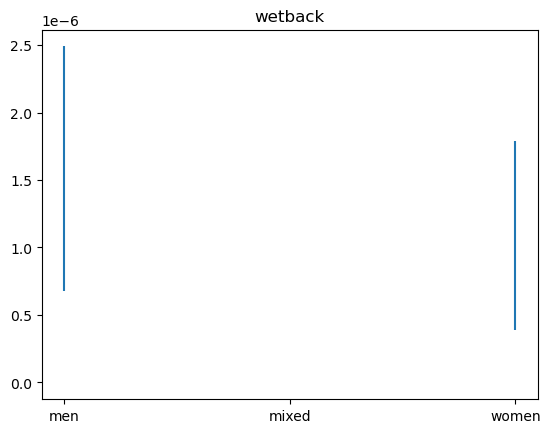

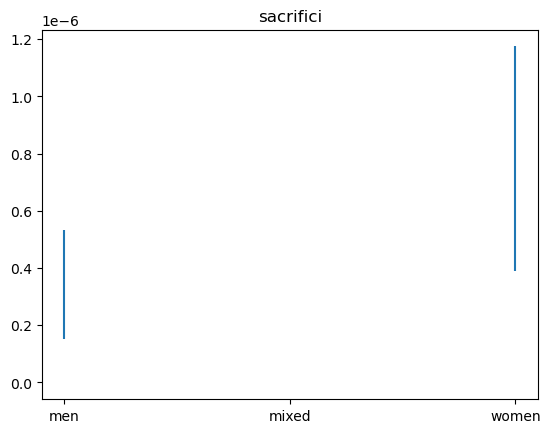

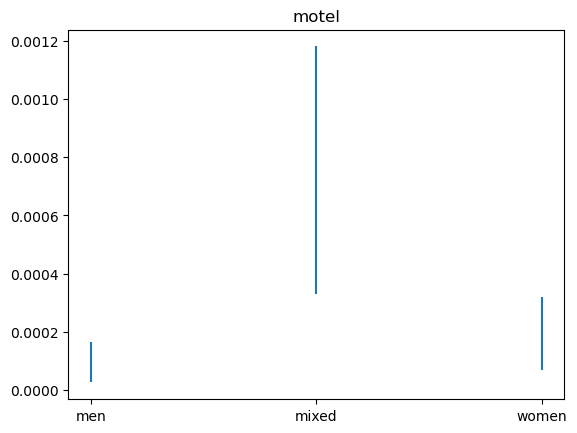

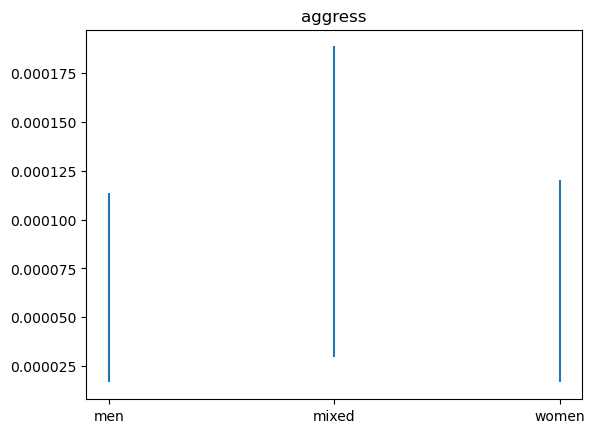

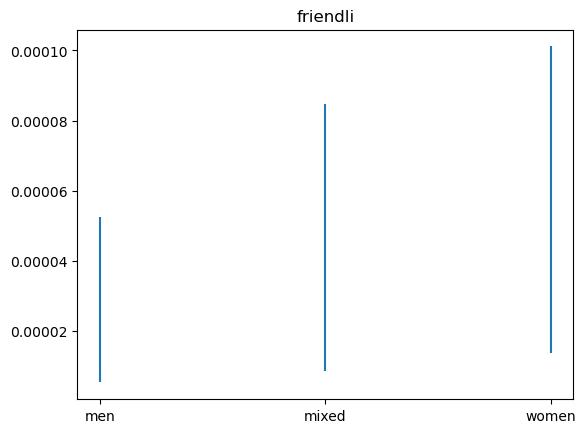

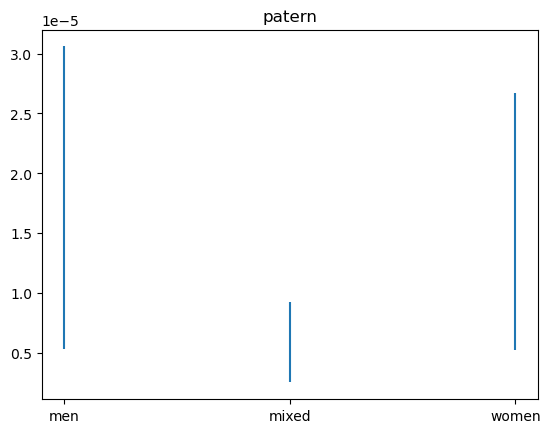

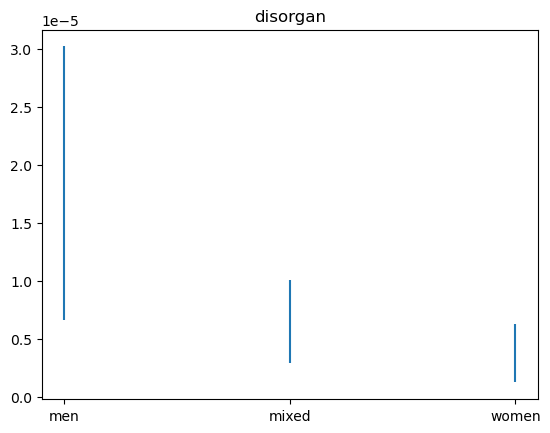

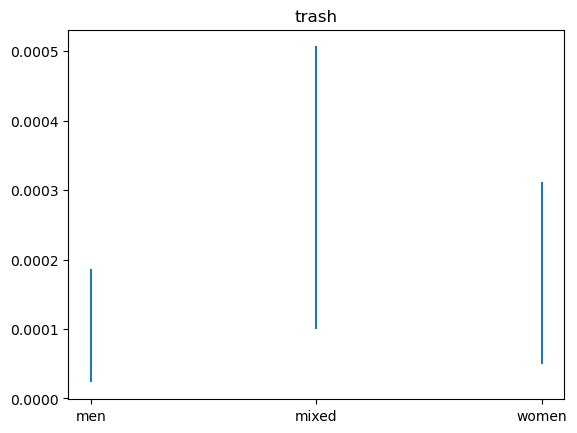

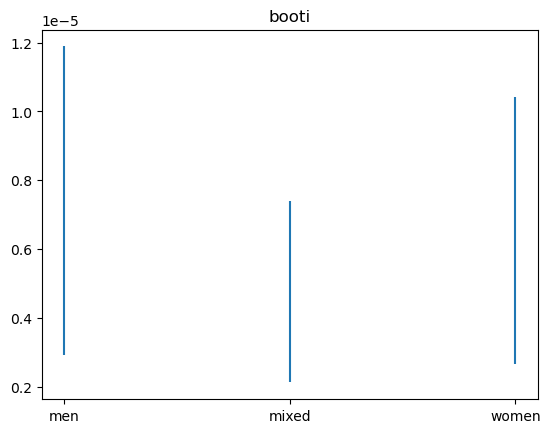

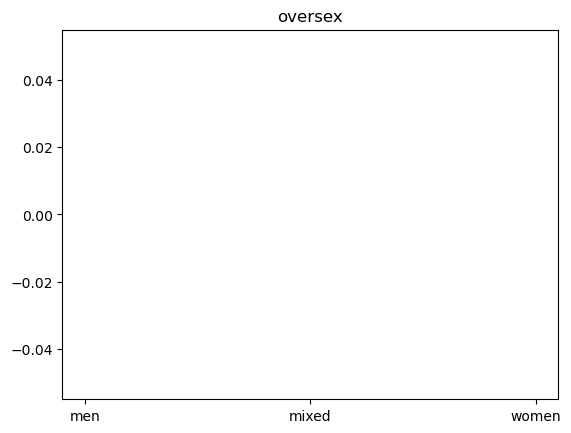

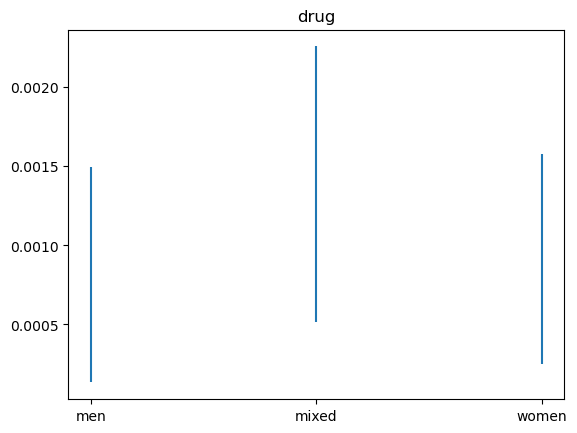

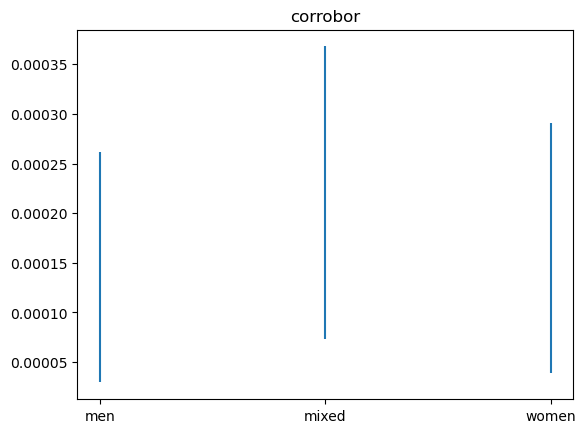

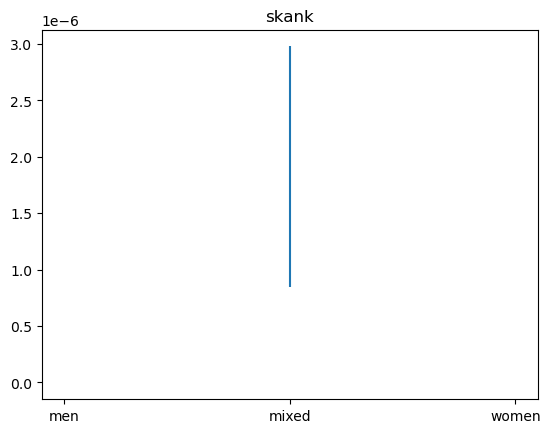

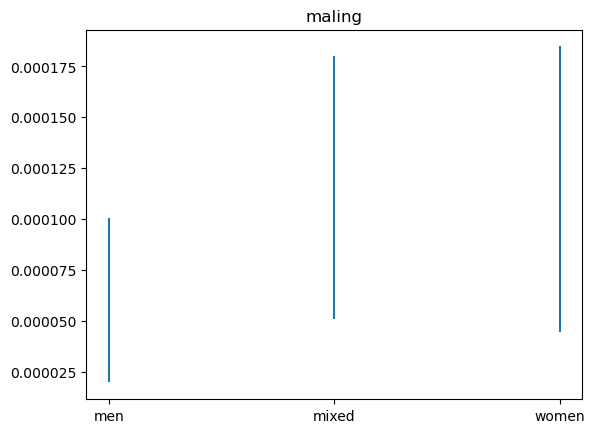

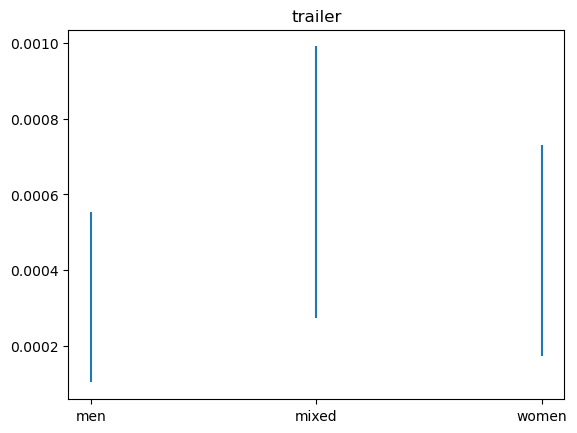

<Figure size 640x480 with 0 Axes>

In [34]:
for keyword in unique_keywords:
    grph = keyword_ci[keyword_ci['keyword'] == keyword]
    plt.errorbar(x=grph['gender'], y=grph['keyword_normalized_term_frequency'], 
                 yerr=(grph['keyword_normalized_term_frequency_L'], grph['keyword_normalized_term_frequency_U']), 
                 linestyle='None')
    plt.title(keyword)
    plt.show()
    plt.clf()

## Chi-square Test

In [28]:
## Chi-square test

gender_count = df_agg.copy()[['gender', 'total_words']]

actuals = point_estimate_theme.groupby('gender')['theme_keyword_count'].sum().reset_index()
actuals = pd.merge(gender_count, actuals)
actuals['nontheme'] = actuals['total_words'] - actuals['theme_keyword_count']
actuals['theme'] = 'nontheme'
actuals = actuals[['gender', 'theme', 'nontheme']]
actuals.columns = ['gender', 'theme', 'theme_keyword_count']
actuals = pd.concat([actuals[['gender', 'theme', 'theme_keyword_count']], 
                     point_estimate_theme[['gender', 'theme', 'theme_keyword_count']]])
actuals.columns = ['gender', 'theme', 'actual']

theme_count = actuals.groupby('theme')['actual'].sum().reset_index()
theme_count['prop_theme'] = theme_count['actual'] / theme_count['actual'].sum()

expected = pd.merge(gender_count, theme_count, how='cross')
expected['expected'] = np.round(expected['total_words'] * expected['prop_theme']).astype(int)
expected = expected[['gender', 'theme', 'expected']]
expected.loc[6, 'expected'] += 1 ## so that expected/actual frequencies match (if not, off by one due to rounding error)

chisq = pd.merge(actuals, expected)
chisq['over'] = np.where(chisq['actual'] > chisq['expected'], 'over', '')
print(chisq)
chisquare(chisq['actual'], chisq['expected'])

   gender             theme    actual  expected  over
0     men          nontheme  13080564  13072254  over
1   mixed          nontheme   2325846   2328134      
2   women          nontheme   7616386   7622408      
3     men         addiction     23265     22989  over
4     men      discrediting      6437      7307      
5     men            gender     28126     30846      
6     men  hypersexualizing      6033      6883      
7     men       immigration     18294     20349      
8     men     mental health     14597     13504  over
9     men         parenting     33915     37775      
10    men     pathologizing      8136      9599      
11    men           poverty      6513      7323      
12    men     racial tropes     11691      8455  over
13    men         sexuality       319       606      
14  mixed         addiction      4828      4094  over
15  mixed      discrediting       978      1301      
16  mixed            gender      6024      5494  over
17  mixed  hypersexualizing 

Power_divergenceResult(statistic=np.float64(8751.620807434518), pvalue=np.float64(0.0))